<div style="border:solid green 2px; padding: 20px">
    
<b>Артем, привет!</b> Мы рады тебя видеть на территории код-ревьюеров 😎. Ты проделал большую работу над проектом, но давай познакомимся и сделаем его еще лучше! У нас тут своя атмосфера и несколько правил:


1. Это Александр Матвеевский. Я работаю код-ревьюером, моя основная цель — не указать на совершенные тобою ошибки, а поделиться своим опытом и помочь тебе стать дата-специалистом.
2. Общаемся на ты.
3. Если хочешь написать, спросить - не нужно стесняться. Только выбери свой цвет для комментария.  
4. Это учебный проект, тут можно не бояться сделать ошибку.  
5. У нас с тобой 6 попыток для сдачи проекта.  
6. Let's Go!

---

Я буду красить комментарии цветом, пожалуйста, не удаляй их:

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

Такой комментарий нужно исправить обязательно, он критически влияет на удачное выполнение проекта.
</div>
    
---

<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__


Такой комментарий является рекомендацией или советом. Можешь использовать их на своё усмотрение.
</div>

---

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Такой комментарий  говорит о том, что было сделано что-то качественное и правильное =)
</div>
    
---
    
Предлагаю работать над проектом в диалоге: если ты что-то меняешь в проекте или отвечаешь на мои комментарии — пиши об этом. Мне будет легче отследить изменения, если ты выделишь свои комментарии:   
    
<div class="alert alert-info"> <b>Комментарии студента:</b> Например, вот так.</div>
    
Всё это поможет выполнить повторную проверку твоего проекта оперативнее. Если будут какие-нибудь вопросы по моим комментариям, пиши, будем разбираться вместе :)    
    
---

# Прогнозирование вероятности клика (CTR) в RTB-аукционе для AdTech-платформы Advandex

Автор: Мельников Артём Владимирович

Дата: 02.04.2026

# Цели и задачи проекта

Цель проекта - разработать модель бинарной классификации, которая предсказывает вероятность клика по рекламному объявлению для AdTech-платформы Advandex.

В рамках проекта необходимо решить следующие задачи:

- изучить структуру и качество исходного датасета;
- провести исследовательский анализ данных и определить особенности целевой переменной;
- подготовить данные для моделирования: обработать пропуски, выделить числовые и категориальные признаки, выбрать способы кодирования и масштабирования;
- выполнить отбор признаков с помощью фильтрационных методов и методов-обёрток;
- обучить базовые модели классификации, включая DummyClassifier, LogisticRegression и SVC;
- подобрать гиперпараметры моделей с помощью GridSearchCV и кросс-валидации;
- оценить качество моделей с использованием метрик PR-AUC, Log Loss и оценки Бриера;
- провести калибровку вероятностей, чтобы предсказанные значения лучше соответствовали реальной частоте кликов;
- сравнить качество моделей до и после калибровки;
- выделить наиболее значимые признаки и интерпретировать их влияние на вероятность клика;
- сохранить финальный пайплайн и модель для дальнейшего использования в продакшене.

Особенность проекта заключается в том, что для рекламного аукциона важна не только точность классификации, но и достоверность предсказанных вероятностей. Именно поэтому отдельное внимание уделяется калибровке модели.

# Описание данных

В проекте используется датасет `ds_s16_ad_click_dataset`, содержащий информацию о показах рекламных баннеров и реакции пользователей на эти показы.

Каждая строка датасета соответствует одному событию показа рекламного объявления. Для каждого показа собраны признаки, описывающие контекст аукциона, рекламную площадку, рекламируемое приложение, устройство пользователя, параметры баннера, а также дополнительные машинно-сгенерированные признаки.

Целевая переменная - `click`, бинарный признак, который показывает, был ли совершен клик по рекламному баннеру:

- `1` - клик был;
- `0` - клика не было.

Данные представлены в виде готовой аналитической витрины. Это означает, что признаки уже собраны и приведены к удобному для моделирования формату. При этом часть признаков анонимизирована, поэтому интерпретация некоторых факторов будет ограниченной.

С практической точки зрения датасет отражает задачу прогнозирования CTR - вероятности клика по объявлению. Такие предсказания используются в RTB-аукционах для выбора наиболее выгодного объявления по ожидаемому доходу.

# Состав данных

В датасете представлены следующие группы признаков.

**Идентификаторы и временные признаки**
- `id` - уникальный идентификатор записи о показе;
- `hour` - время показа в формате `YYMMDDHH`.

**Характеристики рекламной площадки**
- `site_id` - идентификатор сайта;
- `site_domain` - домен сайта;
- `site_category` - категория сайта.

**Характеристики рекламируемого приложения**
- `app_id` - идентификатор приложения;
- `app_domain` - домен приложения;
- `app_category` - категория приложения.

**Характеристики устройства и соединения пользователя**
- `device_id` - идентификатор устройства или браузера;
- `device_ip` - IP-адрес устройства;
- `device_model` - модель устройства;
- `device_type` - тип устройства;
- `device_conn_type` - тип сетевого соединения.

**Характеристики баннера и аукциона**
- `banner_pos` - позиция баннера на странице;
- `C1` - анонимизированный признак контекста показа;
- `C14` - `C21` - группа анонимизированных признаков, описывающих параметры баннера, пользователя или аукциона.

**Машинно-сгенерированные признаки**
- `ml_feature_1`, `ml_feature_3` - `ml_feature_6`, `ml_feature_8` - `ml_feature_10` - числовые признаки;
- `ml_feature_2`, `ml_feature_7` - категориальные признаки.

**Целевая переменная**
- `click` - факт клика по рекламному объявлению.

Предварительно можно ожидать, что часть признаков будет иметь высокую кардинальность, например `site_domain`, `device_id`, `device_ip`, `app_id` и другие идентификаторы. Для таких признаков потребуется аккуратный подход к кодированию. Также отдельного внимания заслуживает временной признак `hour`, из которого потенциально можно извлечь полезные компоненты, например день и час показа.

# План работы

Проект будет выполнен поэтапно в соответствии со структурой тетрадки.

**1. Подготовка среды и загрузка данных**
На первом этапе будут подключены библиотеки, зафиксированы версии пакетов, задана константа `RANDOM_SEED` для воспроизводимости и загружен исходный датасет. Далее будет выполнена первичная проверка корректности загрузки данных.

**2. Исследовательский анализ данных**
Будет изучена общая структура датасета, типы признаков, распределение целевой переменной, наличие дисбаланса классов, пропусков, выбросов и взаимосвязей между признаками. На этом этапе также будет выполнен первичный отбор явно бесполезных признаков.

**3. Разделение данных на выборки**
Данные будут разделены на обучающую и тестовую выборки в пропорции 80/20 с использованием стратификации по целевой переменной. Это позволит сохранить исходный баланс классов и обеспечить корректную итоговую оценку модели.

**4. Построение пайплайнов предобработки**
Для числовых и категориальных признаков будут созданы отдельные пайплайны. Для числовых признаков будет выполнено заполнение пропусков и масштабирование. Для категориальных - заполнение пропусков и кодирование с учетом кардинальности признаков. Все преобразования будут объединены через `Pipeline` и `ColumnTransformer`.

**5. Отбор признаков**
На этом этапе будут применены фильтрационные методы и методы-обёртки. Планируется удалить признаки с низкой вариативностью, оценить связь признаков с целевой переменной и выбрать наиболее информативный набор признаков для моделирования.

**6. Обучение базовых моделей**
В качестве отправной точки будет обучен `DummyClassifier`. Затем будут обучены `LogisticRegression` и `SVC` с линейным ядром. Для сравнения моделей будет использована кросс-валидация и метрика PR-AUC как основная для задачи с дисбалансом классов.

**7. Подбор гиперпараметров**
С помощью `GridSearchCV` будет выполнен систематический подбор гиперпараметров для `LogisticRegression` и `SVC`. Основной метрикой оптимизации станет `average_precision`, соответствующая PR-AUC.

**8. Обучение финальной модели**
После выбора лучших гиперпараметров будет обучена финальная версия модели на обучающей выборке. Затем качество модели будет оценено на тестовой выборке с помощью PR-AUC, Log Loss и оценки Бриера.

**9. Калибровка вероятностей**
Поскольку проект требует достоверных вероятностей, для финальной модели будет проведена калибровка методом изотонической регрессии. До и после калибровки будут построены диаграммы калибровки и рассчитаны соответствующие метрики.

**10. Оценка качества калибровки**
Будут дополнительно рассчитаны показатели качества калибровки, включая оценку Бриера, ECE и MCE. Это позволит понять, насколько хорошо вероятности модели соответствуют реальным частотам кликов.

**11. Финальный отчёт и выводы**
На заключительном этапе будут собраны все ключевые результаты: сравнение моделей, метрики до и после калибровки, наиболее значимые признаки и практические выводы по проекту.

**12. Сохранение модели**
Финальный пайплайн предобработки, обученная модель и список выбранных признаков будут сохранены. Также будет проведена проверка загрузки артефактов и выполнения предсказаний на новых данных.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Есть внятное описание проекта, целей и плана работы

# Структура проекта

## 1. Подготовка среды и загрузка данных

#### 1.1 Подготовьте библиотеки
- Создайте файл `requirements.txt` с фиксированными версиями всех пакетов.
- Импортируйте все необходимые библиотеки.
- Настройте параметры отображения графиков и датафреймов.

#### 1.2 Зафиксируйте константу для воспроизводимости
- Установите константу `RANDOM_SEED`.
- Применяйте её ко всем алгоритмам, которые её поддерживают.

#### 1.3 Загрузите данные
- Прочитайте CSV-файл с данными. Путь к файлу: `'/datasets/ds_s16_ad_click_dataset.csv'`
- Выведите размер датасета, первые несколько строк и информацию о типах столбцов.
- Проверьте успешность загрузки данных.

In [1]:
# Обновим библиотеки
# Обновим scikit-learn
!pip install --upgrade scikit-learn -q

In [2]:
# Подключим библиотеки с помощью try/except, чтобы ноутбук не падал,
# если какая-то библиотека временно недоступна

try:
    # =====================================
    # Базовые библиотеки
    # =====================================
    import numpy as np
    import pandas as pd
    import json
    import joblib
    
    # =====================================
    # Scipy
    # =====================================
    import scipy

    # =====================================
    # Визуализация
    # =====================================
    import matplotlib
    import matplotlib.pyplot as plt
    import seaborn as sns

    # =====================================
    # Корреляции (phik)
    # =====================================
    try:
        from phik import phik_from_array
        from phik.report import plot_correlation_matrix
        import phik
    except ImportError:
        !pip install phik -q
        from phik import phik_from_array
        from phik.report import plot_correlation_matrix
        import phik

    # =====================================
    # Target Encoding
    # =====================================
    try:
        from category_encoders import TargetEncoder
        import category_encoders
    except ImportError:
        !pip install category-encoders==2.2.2 -q
        from category_encoders import TargetEncoder
        import category_encoders

    # =====================================
    # Sklearn
    # =====================================
    import sklearn

    from sklearn.model_selection import (
        train_test_split,
        StratifiedKFold,
        GridSearchCV,
        cross_validate
    )

    from sklearn.pipeline import Pipeline
    from sklearn.compose import ColumnTransformer

    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import StandardScaler, OneHotEncoder

    from sklearn.feature_selection import (
        VarianceThreshold,
        RFECV,
        SequentialFeatureSelector
    )

    from sklearn.linear_model import LogisticRegression
    from sklearn.svm import SVC, LinearSVC
    from sklearn.dummy import DummyClassifier

    from sklearn.base import BaseEstimator, TransformerMixin
    from sklearn.base import clone

    # =====================================
    # Метрики
    # =====================================
    from sklearn.metrics import (
        average_precision_score,
        precision_recall_curve,
        precision_score,
        recall_score,
        f1_score,
        log_loss,
        brier_score_loss
    )

    # =====================================
    # Калибровка
    # =====================================
    from sklearn.calibration import (
        CalibratedClassifierCV,
        calibration_curve
    )
    from sklearn.isotonic import IsotonicRegression
    from scipy.special import expit

    # =====================================
    # Предупреждения
    # =====================================
    import warnings
    from sklearn.exceptions import ConvergenceWarning

    warnings.filterwarnings("ignore", category=ConvergenceWarning)
    warnings.filterwarnings("ignore", category=FutureWarning)
    warnings.filterwarnings("ignore")

    print("Библиотеки успешно импортированы")

except ImportError as e:
    print(f"Ошибка импорта библиотек: {e}")

Библиотеки успешно импортированы


<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__

Импорты перегружены и местами избыточны. Например, часть библиотек и объектов подключена заранее, но дальше либо не используется

In [3]:
# Зафиксируем версии библиотек в requirements.txt

requirements = f"""
pandas=={pd.__version__}
numpy=={np.__version__}
joblib=={joblib.__version__}
scikit-learn=={sklearn.__version__}
matplotlib=={matplotlib.__version__}
seaborn=={sns.__version__}
phik=={phik.__version__}
category-encoders=={category_encoders.__version__}
scipy=={scipy.__version__}
""".strip()

with open("requirements.txt", "w") as f:
    f.write(requirements)

print("requirements.txt создан:\n")
print(requirements)

requirements.txt создан:

pandas==1.2.4
numpy==1.21.1
joblib==1.5.3
scikit-learn==1.6.1
matplotlib==3.3.4
seaborn==0.11.1
phik==0.12.5
category-encoders==2.2.2
scipy==1.9.1


In [4]:
# Зафиксируем random_state для воспроизводимости результатов

RANDOM_SEED = 42
RANDOM_STATE = RANDOM_SEED

# Для numpy
np.random.seed(RANDOM_SEED)

print(f"RANDOM_SEED = {RANDOM_SEED}")
print(f"RANDOM_STATE = {RANDOM_STATE}")

RANDOM_SEED = 42
RANDOM_STATE = 42


<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

RANDOM_STATE зафиксирован

In [5]:
# Настройка отображения данных и графиков

# Настройки отображения pandas
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

# Настройки визуализации (универсально)
try:
    plt.style.use("seaborn-v0_8")
except:
    plt.style.use("seaborn")  # fallback для старых версий

sns.set_context("notebook")

# Параметры графиков
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# Для Jupyter
%matplotlib inline

# Функция для отображения значений над столбцами
def add_bar_labels(ax, fmt="{:.4f}", offset=0.0):
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(fmt.format(height),
                    (p.get_x() + p.get_width() / 2, height + offset),
                    ha='center', va='bottom')

print("Настройки отображения успешно применены")

Настройки отображения успешно применены


In [6]:
# Загрузка данных

DATA_PATH = '/datasets/ds_s16_ad_click_dataset.csv'

try:
    df = pd.read_csv(DATA_PATH, sep=',', decimal='.')
    
    print("Данные успешно загружены\n")
    
    print("Размер датасета:")
    print(df.shape)
    
    print("\nПервые строки:")
    display(df.head())
    
    print("\nИнформация о данных:")
    df.info()

except Exception as e:
    print(f"Ошибка загрузки данных: {e}")

Данные успешно загружены

Размер датасета:
(50000, 34)

Первые строки:


,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,app_category,device_id,device_ip,device_model,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21,ml_feature_1,ml_feature_2,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10
0,10052627552648869888.000000,1,14102100,1005,1,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,488a9a3e,31025cda,1,0,17614,320,50,1993,2,1063,-1,33,-0.996823,A,0.666588,0,0.817292,0.993275,Z,-0.619959,0.433666,0.274038
1,10105971003478261760.000000,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,75bb1b58,2ee63ff8,1,0,15701,320,50,1722,0,35,-1,79,-0.391309,C,5.146789,1,-0.883865,-0.825722,X,0.576526,-0.318558,-0.132851
2,10120475683957065728.000000,0,14102100,1005,0,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,07d7df22,a99f214a,285263b0,d780319b,1,0,17914,320,50,2043,2,39,100084,32,-2.112732,D,7.169348,0,-0.859440,-0.338365,Y,-0.440047,-0.345412,0.340487
3,1021995395003627776.000000,0,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,39cfef32,d9b5648e,0f2161f8,a99f214a,18190986,f4fffcd0,1,0,21611,320,50,2480,3,297,100111,61,0.332707,A,-0.290708,1,0.062795,0.062934,Y,0.551982,0.733382,-0.198542
4,10234552355176744960.000000,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,b66e5482,a0f5f879,1,0,15702,320,50,1722,0,35,100084,79,1.166623,A,6.319134,1,-0.675276,0.797144,X,0.640827,0.297955,-0.136909



Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50000 non-null  float64
 1   click             50000 non-null  int64  
 2   hour              50000 non-null  int64  
 3   C1                50000 non-null  int64  
 4   banner_pos        50000 non-null  int64  
 5   site_id           50000 non-null  object 
 6   site_domain       50000 non-null  object 
 7   site_category     50000 non-null  object 
 8   app_id            50000 non-null  object 
 9   app_domain        50000 non-null  object 
 10  app_category      50000 non-null  object 
 11  device_id         50000 non-null  object 
 12  device_ip         50000 non-null  object 
 13  device_model      50000 non-null  object 
 14  device_type       50000 non-null  int64  
 15  device_conn_type  50000 non-null  int64  
 16  C14               

**Выводы по этапу подготовки среды и загрузки данных**

На данном этапе была подготовлена среда для работы и успешно загружен исходный датасет.

Были выполнены следующие шаги:

- подключены все необходимые библиотеки для анализа данных, визуализации и машинного обучения;
- настройна обработка исключений при импорте библиотек, что повышает устойчивость ноутбука;
- зафиксированы версии используемых библиотек в файле requirements.txt для обеспечения воспроизводимости;
- установлена константа RANDOM_SEED, которая будет использоваться на всех этапах обучения моделей;
- настроены параметры отображения таблиц и графиков для удобства анализа;
- успешно загружен датасет из указанного источника и проверена корректность загрузки.

Основные характеристики датасета:

- размер данных: 50 000 строк и 34 признака;
- отсутствуют пропущенные значения;
- присутствуют как числовые, так и категориальные признаки;
- целевая переменная click представлена в бинарном формате;
- часть признаков является анонимизированной, что ограничивает их интерпретацию, но не влияет на моделирование.

Дополнительно можно отметить:

- признак id представлен в формате float, что может быть технической особенностью выгрузки и не несёт полезной информации для модели;
- в данных присутствует большое количество категориальных признаков с потенциально высокой кардинальностью, что потребует аккуратного подхода к кодированию на следующих этапах.

Данные успешно подготовлены для дальнейшего исследовательского анализа.

<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__

Лучше держать импорты компактнее и подключать только то, что реально используется

## 2. Исследовательский анализ данных (EDA)

#### 2.1 Опишите базовую информацию о датасете
- Определите, сколько объектов и признаков содержится в данных.
- Выясните, какие типы данных представлены (числовые, категориальные).
- Дайте общее описание: укажите, что известно о пользователях и рекламе.

#### 2.2 Анализ целевой переменной
- Проанализируйте, как распределена целевая переменная.
- Определите, есть ли дисбаланс классов. Это важно для выбора метрик.
- Посчитайте долю рекламы, на которую кликнули, и долю рекламы, на которую не кликнули.

#### 2.3 Анализ признаков
- Определите, все ли признаки нужны для обучения модели. Есть ли среди них явно бесполезные?
- Опишите, какие признаки категориальные, а какие — числовые.
- Проведите первичный отбор: удалите ненужные признаки.

#### 2.4 Анализ пропущенных значений
- Проверьте долю пропусков в каждом признаке.
- Выберите корректную стратегию для заполнения пропусков — удаление, среднее, медиана, мода. Выбор обоснуйте.

#### 2.5 Анализ категориальных признаков
- Определите, сколько уникальных значений в каждом категориальном признаке.
- Укажите, какие признаки можно кодировать One-Hot Encoding, а какие требуют специальных методов из-за высокой кардинальности.

#### 2.6 Анализ выбросов и распределений
- Проверьте, есть ли явные выбросы в числовых признаках.
- Опишите, как распределены выбросы — нормально, асимметрично, каким-то другим образом.

#### 2.7 Корреляции
- Определите, какие признаки коррелируют с целевой переменной.
- Выявите сильно скоррелированные признаки, которые можно удалить, если такие есть.

#### 2.8 Выводы по EDA
- Кратко опишите ключевые находки.
- Выберите признаки, которые выглядят наиболее перспективными для модели. Выбор обоснуйте.
- Определите действия по предобработке данных, которые необходимо проделать.

На этом этапе изучим структуру данных, распределение целевой переменной, типы признаков, пропуски, кардинальность категориальных признаков, распределения числовых переменных и их связь с целевой переменной.

Цель этапа - понять, какие признаки потребуют дополнительной обработки, какие преобразования нужны перед моделированием и какие решения стоит заложить в пайплайн предобработки.

In [7]:
# Зафиксируем название целевой переменной
target = "click"

### 2.1 Базовая информация о датасете

Сначала определим размер датасета, количество признаков и распределение типов данных. Это позволит понять общую структуру выборки и заранее выделить группы признаков для последующей обработки.

In [8]:
print("Количество объектов (строк):", df.shape[0])
print("Количество признаков (столбцов):", df.shape[1])

features = [col for col in df.columns if col != target]

cat_cols_raw = df[features].select_dtypes(include=["object"]).columns.tolist()
num_cols_raw = df[features].select_dtypes(include=[np.number]).columns.tolist()

print("Количество признаков object:", len(cat_cols_raw))
print("Количество числовых признаков:", len(num_cols_raw))

display(
    pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values
    })
)

Количество объектов (строк): 50000
Количество признаков (столбцов): 34
Количество признаков object: 11
Количество числовых признаков: 22


,column,dtype
0,id,float64
1,click,int64
2,hour,int64
3,C1,int64
4,banner_pos,int64
5,site_id,object
6,site_domain,object
7,site_category,object
8,app_id,object
9,app_domain,object


Исходный датасет содержит **50 000 объектов** и **34 столбца**. Целевая переменная - `click`, бинарный признак, который показывает факт клика по рекламному объявлению.

По типам данных признаки делятся на две основные группы:

- **11 признаков** имеют тип `object` и являются категориальными в явном виде;
- **22 признака** имеют числовой тип (`int64` и `float64`), не считая целевой переменной.

При этом часть числовых признаков по смыслу также являются категориальными. К ним относятся, например, `C1`, `banner_pos`, `device_type`, `device_conn_type`, а также признаки `C14-C21`. Их числовой формат не означает, что они описывают непрерывные величины - фактически это коды категорий.

Также можно заранее отметить два важных момента:

- `id` является идентификатором записи и не несёт полезной информации для обучения модели;
- `hour` записан в формате `YYMMDDHH` и требует преобразования в более интерпретируемые временные компоненты.

По содержанию данных можно выделить несколько смысловых блоков признаков:

- характеристики рекламной площадки - `site_*`;
- характеристики рекламируемого приложения - `app_*`;
- характеристики устройства пользователя - `device_*`;
- параметры баннера и аукциона - `C*`, `banner_pos`;
- машинно-сгенерированные признаки - `ml_feature_*`.

Таким образом, структура данных соответствует описанию задачи и подходит для дальнейшего анализа и моделирования.

### 2.2 Анализ целевой переменной

Теперь изучим распределение целевой переменной `click`. Это важно, чтобы понять, есть ли дисбаланс классов, и сразу определить, какие метрики качества будут наиболее уместны в проекте.

CTR (доля кликов): 0.1721


,count,share
0,41397,0.827940
1,8603,0.172060


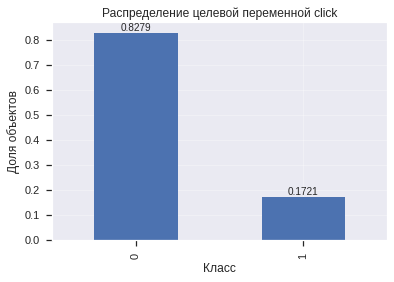

In [9]:
target_share = df[target].value_counts(normalize=True).sort_index()
target_count = df[target].value_counts().sort_index()
ctr = df[target].mean()

print(f"CTR (доля кликов): {ctr:.4f}")

display(
    pd.DataFrame({
        "count": target_count,
        "share": target_share
    })
)

ax = target_share.plot(kind="bar")
add_bar_labels(ax)

ax.set_title("Распределение целевой переменной click")
ax.set_xlabel("Класс")
ax.set_ylabel("Доля объектов")
plt.show()

Средняя доля кликов в выборке составляет **17.21%**, а доля показов без клика - **82.79%**.

В абсолютных значениях это:

- **41 397** показов без клика;
- **8 603** показов с кликом.

Таким образом, в данных наблюдается **заметный дисбаланс классов**: отрицательный класс существенно преобладает над положительным.

Для такой задачи обычной accuracy недостаточно, так как высокая доля нулевого класса может искусственно завышать качество простой модели. Поэтому в проекте в качестве основной метрики будет использоваться **PR-AUC**, так как она лучше отражает способность модели находить редкий положительный класс - клики.

Дополнительно будут использоваться:

- **Log Loss** - для оценки качества вероятностных прогнозов;
- **Brier Score** - для оценки точности и калибровки вероятностей.

Это особенно важно в контексте задачи Advandex, где модель используется для оценки CTR и дальнейшего расчёта ожидаемого дохода в рекламном аукционе.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Дисбаланс классов определен корректно

### 2.3 Анализ признаков

На этом этапе выполним первичный анализ признаков и сразу обработаем временной признак `hour`.

Признак `hour` хранится в формате `YYMMDDHH` и в исходном виде неудобен для анализа и моделирования. Если оставить его как обычное числовое значение, модель будет воспринимать его как линейную числовую шкалу, хотя по смыслу это временная метка. Поэтому преобразуем его в более интерпретируемые компоненты:

- `hour_of_day` - час суток;
- `dayofweek` - день недели;
- `is_weekend` - индикатор выходного дня.

После этого удалим исходный столбец `hour`. Также удалим `id`, так как это идентификатор записи, а не информативный признак.

In [10]:
# Создадим рабочую копию датасета для EDA
df_eda = df.copy()

# Преобразуем hour в интерпретируемые временные признаки
dt = pd.to_datetime(df_eda["hour"].astype(str), format="%y%m%d%H", errors="coerce")

df_eda["hour_of_day"] = dt.dt.hour.astype("Int64")
df_eda["dayofweek"] = dt.dt.dayofweek.astype("Int64")
df_eda["is_weekend"] = (df_eda["dayofweek"] >= 5).astype("Int64")

# Удалим исходный hour и идентификатор id
df_eda = df_eda.drop(columns=["hour", "id"])

print("Размер датасета после преобразования hour и удаления id:", df_eda.shape)

display(df_eda[["hour_of_day", "dayofweek", "is_weekend"]].head())

Размер датасета после преобразования hour и удаления id: (50000, 35)


,hour_of_day,dayofweek,is_weekend
0,0,1,0
1,0,1,0
2,0,1,0
3,0,1,0
4,0,1,0


In [11]:
# Список признаков, которые по смыслу следует считать категориальными
semantic_cat = [
    "C1",
    "banner_pos",
    "device_type",
    "device_conn_type",
    "C14", "C15", "C16", "C17", "C18", "C19", "C20", "C21",
    "hour_of_day",
    "dayofweek",
    "is_weekend",
    "ml_feature_4"   # бинарный признак рассматриваем как категориальный
]

features_eda = [col for col in df_eda.columns if col != target]

cat_cols_obj = df_eda[features_eda].select_dtypes(include=["object"]).columns.tolist()
num_cols_all = df_eda[features_eda].select_dtypes(include=[np.number]).columns.tolist()

cat_cols = sorted(set(cat_cols_obj + semantic_cat))
num_cols = [col for col in num_cols_all if col not in cat_cols]

print("Количество категориальных признаков:", len(cat_cols))
print("Количество числовых признаков:", len(num_cols))

print("\nКатегориальные признаки:")
print(cat_cols)

print("\nЧисловые признаки:")
print(num_cols)

Количество категориальных признаков: 27
Количество числовых признаков: 7

Категориальные признаки:
['C1', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'app_category', 'app_domain', 'app_id', 'banner_pos', 'dayofweek', 'device_conn_type', 'device_id', 'device_ip', 'device_model', 'device_type', 'hour_of_day', 'is_weekend', 'ml_feature_2', 'ml_feature_4', 'ml_feature_7', 'site_category', 'site_domain', 'site_id']

Числовые признаки:
['ml_feature_1', 'ml_feature_3', 'ml_feature_5', 'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10']


На данном этапе были выполнены два важных преобразования:

- исходный признак `hour` был разложен на три более интерпретируемых временных компонента: `hour_of_day`, `dayofweek` и `is_weekend`;
- признак `id` был удалён как неинформативный идентификатор.

После этих изменений в рабочем датасете стало **35 столбцов**, включая целевую переменную.

Признаки были разделены с учётом не только формального типа данных, но и их смысловой природы:

- **числовые признаки** - в основном это непрерывные машинно-сгенерированные `ml_feature_*`;
- **категориальные признаки** - это не только признаки типа `object`, но и часть целочисленных колонок, которые по смыслу представляют категории, а не непрерывные величины.

Отдельно важно отметить признак `ml_feature_4`. Несмотря на числовой формат, он является бинарным и в рамках проекта рассматривается как категориальный признак. Такой подход более согласован с его смыслом и позволяет обрабатывать его вместе с другими дискретными признаками.

Такое разделение признаков более корректно для дальнейшего построения пайплайна, поскольку позволяет отдельно обрабатывать:

- числовые признаки - через заполнение пропусков и масштабирование;
- категориальные признаки - через кодирование.

Первичный отбор признаков показал, что `id` действительно не нужен для модели, а временной признак `hour` в исходном виде лучше не использовать. Его преобразование в `hour_of_day`, `dayofweek` и `is_weekend` делает временную информацию более интерпретируемой и пригодной для анализа и последующего моделирования.

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
ml_feature_4 оставлен в числовом блоке, хотя его надо рассматривать как бинарную категорию

<div class="alert alert-info"> 
<b>Комментарий студента:</b> 

Александр, привет!

Спасибо за замечание. 
    
Я пересмотрел обработку признака **ml_feature_4**. Согласен, что его корректнее рассматривать как категориальный, несмотря на числовой тип.

Аргументация следующая:

- признак принимает ограниченное число значений (по факту бинарный);
- значения не отражают непрерывную шкалу и не имеют метрического смысла;
- операции масштабирования (StandardScaler) для него некорректны с точки зрения интерпретации;
- с точки зрения модели он ближе к индикатору (флагу), чем к количественной переменной.

Поэтому ml_feature_4 перенесён в категориальный блок и обрабатывается через One-Hot Encoding.

Такой подход:

- корректнее отражает природу признака;
- согласуется с обработкой других дискретных признаков;
- исключает искажение его влияния при масштабировании.

Дополнительно это обеспечивает единообразие пайплайна: все дискретные признаки обрабатываются через категориальные трансформации, а непрерывные - через числовой пайплайн.

</div>

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №2__
 
Хорошо) Спасибо за правку

### Анализ пропущенных значений

Проверим, есть ли в датасете пропуски. Даже если в текущей выборке пропусков не окажется, это всё равно важно проверить, чтобы заранее определить стратегию обработки пропущенных значений в пайплайне.

In [12]:
missing_share = df_eda.isna().mean().sort_values(ascending=False)
missing_count = df_eda.isna().sum().sort_values(ascending=False)

missing_table = pd.DataFrame({
    "missing_count": missing_count,
    "missing_share": missing_share
})

display(missing_table[missing_table["missing_count"] > 0])

print("Общее количество пропусков:", df_eda.isna().sum().sum())

,missing_count,missing_share


Общее количество пропусков: 0


Пропущенные значения в текущем датасете **отсутствуют**. Все столбцы содержат непустые значения.

Тем не менее, при построении итогового пайплайна предобработки обработка пропусков всё равно будет предусмотрена. Это важно для устойчивости решения в продакшене, где новые данные могут содержать пропуски.

Планируемая стратегия обработки пропусков:

- для числовых признаков - заполнение **медианой**;
- для категориальных признаков - заполнение отдельной категорией, например **"missing"**.

Выбор медианы для числовых признаков обусловлен тем, что она устойчивее к выбросам, чем среднее. Для категориальных признаков отдельная категория позволит сохранить информацию о факте отсутствия значения.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Проверка пропусков выполнена корректно

### 2.5 Анализ категориальных признаков

Теперь оценим кардинальность категориальных признаков - то есть количество уникальных значений в каждом из них. Это необходимо для выбора способа кодирования:

- признаки с низкой кардинальностью можно кодировать с помощью One-Hot Encoding;
- признаки с высокой кардинальностью лучше кодировать с помощью Target Encoding, чтобы избежать чрезмерного роста размерности.

In [13]:
cardinality = df_eda[cat_cols].nunique(dropna=False).sort_values(ascending=False)

display(cardinality.to_frame(name="n_unique"))

print("Максимальная кардинальность:", cardinality.max())
print("Минимальная кардинальность:", cardinality.min())

,n_unique
device_ip,41455
device_id,8580
device_model,2521
C14,1497
site_id,1160
site_domain,1013
app_id,976
C17,387
C20,149
app_domain,67


Максимальная кардинальность: 41455
Минимальная кардинальность: 2


In [14]:
# Разделим категориальные признаки по кардинальности
low_cardinality_cols = cardinality[cardinality <= 20].index.tolist()
high_cardinality_cols = cardinality[cardinality > 20].index.tolist()

# hour_of_day оставим в One-Hot Encoding как интерпретируемый признак
if "hour_of_day" in high_cardinality_cols:
    high_cardinality_cols.remove("hour_of_day")
    low_cardinality_cols.append("hour_of_day")

low_cardinality_cols = sorted(low_cardinality_cols)
high_cardinality_cols = sorted(high_cardinality_cols)

print("Признаки с низкой кардинальностью (One-Hot Encoding):")
print(low_cardinality_cols)

print("\nПризнаки с повышенной кардинальностью (Target Encoding):")
print(high_cardinality_cols)

Признаки с низкой кардинальностью (One-Hot Encoding):
['C1', 'C15', 'C16', 'C18', 'banner_pos', 'dayofweek', 'device_conn_type', 'device_type', 'hour_of_day', 'is_weekend', 'ml_feature_2', 'ml_feature_4', 'ml_feature_7', 'site_category']

Признаки с повышенной кардинальностью (Target Encoding):
['C14', 'C17', 'C19', 'C20', 'C21', 'app_category', 'app_domain', 'app_id', 'device_id', 'device_ip', 'device_model', 'site_domain', 'site_id']


Категориальные признаки в датасете заметно различаются по количеству уникальных значений.

На этапе EDA эта оценка используется как **предварительный ориентир**, чтобы понять структуру признаков и выбрать возможную стратегию кодирования. При этом важно учитывать, что окончательное разделение признаков по кардинальности для построения модели должно выполняться **только на обучающей выборке**, чтобы избежать утечки данных. Именно такой финальный расчёт будет выполнен далее в разделе предобработки.

На текущем этапе можно выделить две основные группы.

**Признаки с низкой кардинальностью.** 

К этой группе относятся признаки с небольшим числом уникальных значений, например:

- `banner_pos`
- `device_type`
- `device_conn_type`
- `ml_feature_2`
- `ml_feature_4`
- `ml_feature_7`
- `dayofweek`
- `is_weekend`
- часть признаков `C*`

Для таких признаков разумно рассматривать **One-Hot Encoding**, так как число создаваемых столбцов будет умеренным и не приведёт к существенному росту размерности.

Отдельно отметим, что признак `hour_of_day` содержит 24 уникальных значения и формально превышает выбранный порог, однако он остаётся компактным и интерпретируемым. Поэтому его также можно отнести к кандидатам на One-Hot Encoding.

**Признаки с высокой кардинальностью.** 

К этой группе относятся признаки вроде:

- `device_ip`
- `device_id`
- `device_model`
- `site_id`
- `site_domain`
- `app_id`
- `app_domain`
- `C14`

Для них применение One-Hot Encoding привело бы к сильному росту размерности и разреженности матрицы признаков. Поэтому для таких признаков целесообразно рассматривать **Target Encoding** или исключение части признаков при необходимости.

В качестве рабочего порога на этапе EDA используется значение **20 уникальных категорий**. Это удобное эвристическое правило для предварительного анализа. Окончательная группировка признаков для модели будет подтверждена позже уже на train-выборке.

Таким образом, по итогам EDA можно зафиксировать предварительную стратегию кодирования:

- **One-Hot Encoding** - для признаков с низкой кардинальностью;
- **Target Encoding** - для признаков с высокой кардинальностью.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__
    
Кардинальность посчитана на train, а не на полном датасете    

<div class="alert alert-info"> 
<b>Комментарий студента:</b> 

Соглашусь. Для финальной настройки модели и выбора стратегии кодирования корректно опираться именно на обучающую выборку. В текущем разделе EDA расчёт кардинальности оставлен как предварительная оценка на полном датасете, чтобы понять общую структуру признаков.

При этом я отдельно уточнил в тексте, что окончательное разделение признаков по кардинальности для построения модели выполняется позже только на train-выборке, чтобы избежать утечки данных.

</div>

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №2__
 
Учтено

### 2.6 Анализ выбросов и распределений

Рассмотрим распределения числовых признаков и оценим наличие выбросов. Это поможет понять, нужны ли дополнительные преобразования перед обучением моделей.

In [15]:
display(df_eda[num_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
ml_feature_1,50000.000000,-0.002445,1.000280,-4.631262,-0.677784,-0.003776,0.673534,3.793828
ml_feature_3,50000.000000,-0.036381,5.792335,-9.999742,-5.059555,-0.056155,4.985939,9.999975
ml_feature_5,50000.000000,0.034729,1.002116,-4.631853,-0.639829,0.028112,0.707594,4.230623
ml_feature_6,50000.000000,0.022948,0.656690,-1.000000,-0.579775,0.037786,0.637131,1.000000
ml_feature_8,50000.000000,0.025465,0.578026,-0.999965,-0.470627,0.027348,0.521117,1.119858
ml_feature_9,50000.000000,0.035361,0.505034,-2.147526,-0.304077,0.035985,0.374152,2.120786
ml_feature_10,50000.000000,0.020226,0.303309,-1.287965,-0.182386,0.018930,0.224080,1.202300


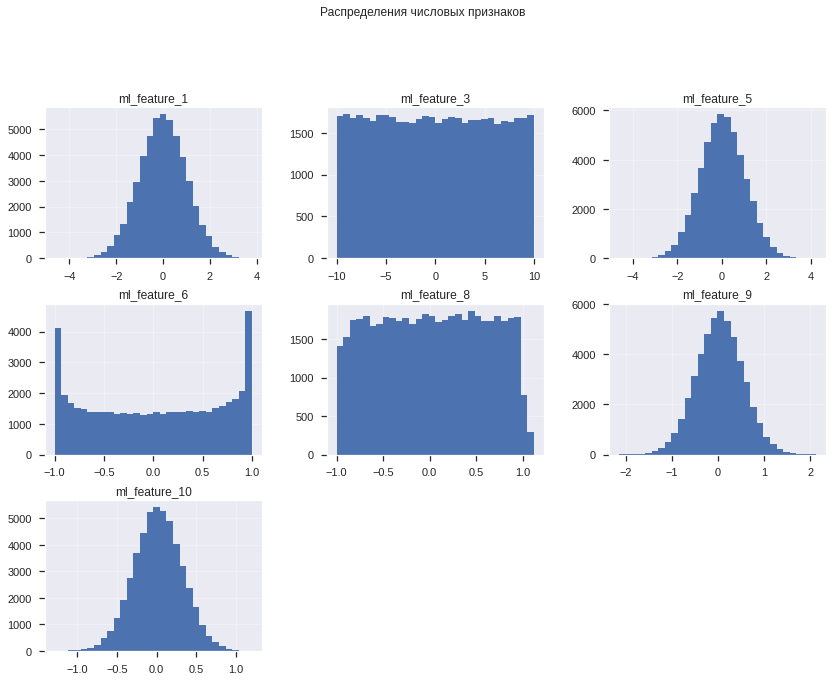

In [16]:
df_eda[num_cols].hist(bins=30, figsize=(14, 10))
plt.suptitle("Распределения числовых признаков", y=1.02)
plt.show()

In [17]:
# Оценим долю выбросов по IQR-правилу
outlier_share = {}

for col in num_cols:
    q1 = df_eda[col].quantile(0.25)
    q3 = df_eda[col].quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    share = ((df_eda[col] < lower_bound) | (df_eda[col] > upper_bound)).mean()
    outlier_share[col] = share

outlier_share = pd.Series(outlier_share).sort_values(ascending=False)

display(outlier_share.to_frame(name="outlier_share"))

,outlier_share
ml_feature_9,0.007740
ml_feature_5,0.007200
ml_feature_10,0.007040
ml_feature_1,0.006940
ml_feature_3,0.000000
ml_feature_6,0.000000
ml_feature_8,0.000000


В датасете выделено **7 числовых признаков**. Это в основном непрерывные машинно-сгенерированные признаки `ml_feature_*`.

По их распределениям можно отметить следующее:

- часть признаков имеет форму, близкую к симметричной;
- некоторые признаки ограничены относительно узким диапазоном значений;
- резких аномалий или экстремально длинных хвостов визуально не наблюдается.

Дополнительная оценка выбросов по IQR-критерию показала, что доля выбросов по каждому признаку невелика. Это означает, что существенных проблем, требующих агрессивной обработки выбросов, на данном этапе не видно.

Следовательно:

- удалять наблюдения из-за выбросов не требуется;
- логарифмирование или клиппинг числовых признаков не нужны;
- для моделей, чувствительных к масштабу признаков, достаточно будет применить `StandardScaler` в пайплайне предобработки.

Это особенно актуально для SVM и логистической регрессии.

Отдельно стоит отметить, что бинарный признак `ml_feature_4` был ранее перенесён в категориальный блок, поэтому в анализе числовых признаков он больше не рассматривается как непрерывный числовой признак.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Согласен с решением не удалять выбросы

### 2.7 Корреляции и связь признаков с целевой переменной

Поскольку в датасете присутствуют признаки разных типов, а целевая переменная бинарная, для оценки связи признаков с `click` удобнее использовать коэффициент **phi_k**. Он позволяет учитывать нелинейные зависимости и работает как с числовыми, так и с категориальными признаками.

Дополнительно для числовых признаков посмотрим обычную матрицу корреляций Пирсона, чтобы проверить наличие мультиколлинеарности.

In [18]:
# Оценим долю уникальных значений по признакам
unique_ratio = (df_eda.nunique(dropna=False) / len(df_eda)).sort_values(ascending=False)
display(unique_ratio.head(20).to_frame(name="unique_ratio"))

# Исключим признаки с почти полной уникальностью значений
# Для таких признаков phi_k может давать нестабильные и трудноинтерпретируемые оценки
bad_cols = unique_ratio[unique_ratio >= 0.95].index.tolist()

candidate_cols = [col for col in df_eda.columns if col not in ([target] + bad_cols)]

phik_scores = {
    col: phik_from_array(df_eda[col].values, df_eda[target].values)
    for col in candidate_cols
}

phik_with_target = pd.Series(phik_scores).sort_values(ascending=False)

print("Исключены из phi_k-анализа признаки с почти полной уникальностью значений:")
print(bad_cols)

display(phik_with_target.head(20).to_frame(name="phi_k_with_target"))

,unique_ratio
ml_feature_10,1.000000
ml_feature_9,1.000000
ml_feature_8,1.000000
ml_feature_6,1.000000
ml_feature_5,1.000000
ml_feature_3,1.000000
ml_feature_1,1.000000
device_ip,0.829100
device_id,0.171600
device_model,0.050420


Исключены из phi_k-анализа признаки с почти полной уникальностью значений:
['ml_feature_10', 'ml_feature_9', 'ml_feature_8', 'ml_feature_6', 'ml_feature_5', 'ml_feature_3', 'ml_feature_1']


,phi_k_with_target
site_id,0.336163
C14,0.327858
C17,0.323409
site_domain,0.320956
device_ip,0.270528
C18,0.257840
C21,0.242703
app_id,0.221436
device_model,0.219222
C19,0.217140


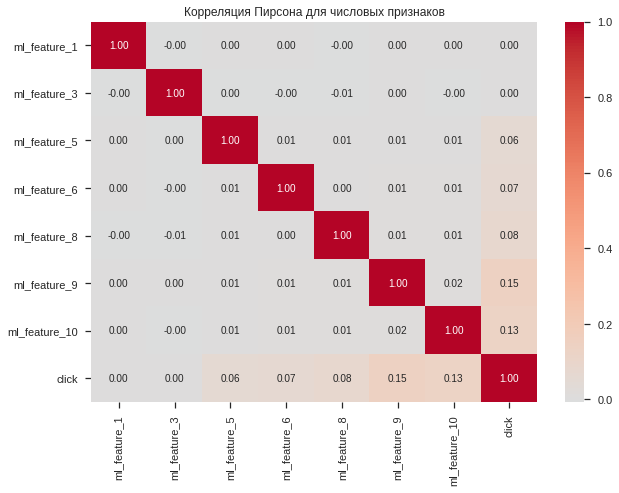

In [19]:
# Корреляция Пирсона только для числовых признаков
pearson_corr = df_eda[num_cols + [target]].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Корреляция Пирсона для числовых признаков")
plt.show()

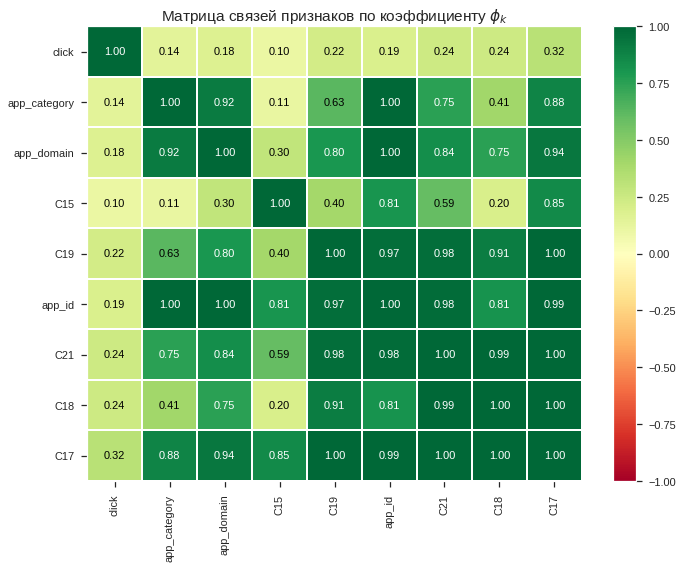

In [20]:
# Считаем количество уникальных значений один раз
nunique_series = df_eda.nunique()
high_card_cols = nunique_series[nunique_series > 1000].index.tolist()

# Возьмём меньше признаков для визуализации
top_features = [
    col for col in phik_with_target.head(15).index.tolist()
    if col not in high_card_cols
][:8]

cols_for_matrix = top_features + [target]

interval_cols = [
    col for col in cols_for_matrix
    if col.startswith("ml_feature_") and pd.api.types.is_numeric_dtype(df_eda[col])
]

# Для ускорения построим phi_k-матрицу на подвыборке
sample_df = df_eda[cols_for_matrix].sample(10000, random_state=RANDOM_SEED)

phik_overview = sample_df.phik_matrix(interval_cols=interval_cols)

plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    title=r"Матрица связей признаков по коэффициенту $\phi_k$",
    fontsize_factor=1.1,
    figsize=(10, 8)
)

Для оценки связи признаков с целевой переменной был использован коэффициент `phi_k`, поскольку:

- целевая переменная `click` бинарная;
- в данных присутствуют как числовые, так и категориальные признаки;
- часть зависимостей может быть нелинейной.

При этом результаты данного этапа следует интерпретировать аккуратно. Это **исследовательский корреляционный анализ**, а не окончательная оценка полезности признаков для модели. Часть признаков была исключена из `phi_k`-анализа из-за почти полной уникальности значений, поскольку для них коэффициент может давать нестабильные или трудноинтерпретируемые оценки связи. Это относится прежде всего к части непрерывных числовых признаков `ml_feature_*`.

Поэтому выводы этого этапа нужно разделять на два уровня:

**1. Что можно считать надёжным результатом анализа**
- среди категориальных признаков действительно есть признаки, демонстрирующие заметную связь с целевой переменной;
- признаки, связанные с площадкой, параметрами аукциона и устройством пользователя, выглядят потенциально перспективными;
- сильной линейной корреляции между числовыми признаками не обнаружено;
- явной мультиколлинеарности среди числовых признаков, требующей немедленного удаления признаков, не выявлено.

**2. Что нельзя трактовать как окончательный вывод об информативности**
- высокое значение `phi_k` не означает автоматически, что признак обязательно окажется полезным в финальной модели;
- низкое значение линейной корреляции не означает, что признак бесполезен, поскольку зависимость может быть нелинейной или проявляться только во взаимодействии с другими признаками;
- ранжирование признаков по `phi_k` и по корреляции Пирсона следует рассматривать только как ориентир для последующего отбора признаков, а не как окончательное основание для удаления признаков.

По матрице корреляции Пирсона видно, что среди числовых признаков наибольшую линейную связь с целевой переменной показывают `ml_feature_9`, `ml_feature_10`, `ml_feature_8`, `ml_feature_6` и `ml_feature_5`. Однако и этот результат отражает только линейную составляющую связи.

Матрица `phi_k` также показывает, что часть категориальных признаков тесно связана между собой. Это может отражать структуру рекламного контекста и вложенность категорий. Однако на данном этапе этих наблюдений недостаточно для удаления признаков, поэтому окончательное решение будет приниматься позже - на этапе отбора признаков с использованием фильтрационных методов и методов-обёрток.

<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__

Лучше было бы четче разделить: какие выводы относятся к реальной информативности признаков, а какие только к ограниченному корреляционному анализу после упрощений

<div class="alert alert-info"> 
<b>Комментарий студента:</b> 

Спасибо, Александр.

Формулировка действительно была слишком общей. Я переработал выводы и теперь отдельно разделил то:
- что можно считать предварительными наблюдениями в рамках корреляционного анализа;
- что нельзя трактовать как окончательный вывод об информативности признаков.
</div>

В ходе исследовательского анализа данных были получены следующие ключевые результаты.

**Структура данных**

Исходный датасет содержит 50 000 объектов и 34 столбца.  
Целевая переменная `click` является бинарной.

Признак `id` был удалён как неинформативный идентификатор.  
Признак `hour` был преобразован в более интерпретируемые временные компоненты:

- `hour_of_day`
- `dayofweek`
- `is_weekend`

**Целевая переменная**

Доля кликов составляет 17.21%.  
В данных наблюдается выраженный дисбаланс классов.

В качестве основной метрики для проекта будет использоваться **PR-AUC**.  
Для оценки качества вероятностей и калибровки дополнительно будут использоваться **Log Loss** и **Brier Score**.

**Признаки**

После преобразования временного признака и удаления `id` в рабочем наборе осталось 35 столбцов, включая целевую переменную.

Все признаки были разделены на:

- **числовые** - в основном непрерывные `ml_feature_*`;
- **категориальные** - как объектные признаки, так и семантически категориальные числовые признаки (`C*`, `device_*`, временные компоненты и бинарный `ml_feature_4`).

Такой подход лучше отражает содержательный смысл данных и позволяет корректнее строить дальнейшую предобработку.

**Пропуски**

Пропущенные значения в текущем датасете отсутствуют.

Несмотря на это, в итоговом пайплайне будет предусмотрена обработка пропусков:

- медианой - для числовых признаков;
- отдельной стратегией заполнения - для категориальных признаков.

**Категориальные признаки**

На этапе EDA выполнена предварительная оценка кардинальности категориальных признаков.

Предварительно можно ожидать, что:

- признаки с низкой кардинальностью будут кодироваться с помощью **One-Hot Encoding**;
- признаки с высокой кардинальностью - с помощью **Target Encoding**.

Признак `hour_of_day`, несмотря на 24 уникальных значения, также выглядит подходящим кандидатом для One-Hot Encoding как компактный и интерпретируемый временной признак.

При этом окончательное разделение признаков по кардинальности для модели должно выполняться только на обучающей выборке. Это будет сделано на следующем этапе.

**Числовые признаки**

Существенных выбросов в числовых признаках не обнаружено.  
Дополнительные нелинейные преобразования не требуются.

Для моделей, чувствительных к масштабу признаков, будет использоваться **StandardScaler**.

**Корреляционный анализ**

Для предварительной оценки связи признаков с целевой переменной использован коэффициент `phi_k`, а для числовых признаков дополнительно построена матрица корреляции Пирсона.

Результаты этого этапа показывают, что:

- признаки, связанные с площадкой, параметрами аукциона и устройством пользователя, выглядят потенциально информативными;
- среди числовых признаков наибольшую линейную связь с целевой переменной показывают `ml_feature_9`, `ml_feature_10`, `ml_feature_8`, `ml_feature_6` и `ml_feature_5`;
- сильной линейной корреляции между числовыми признаками не обнаружено.

При этом важно, что эти результаты являются именно **исследовательскими ориентирами**, а не окончательной оценкой полезности признаков. Решения об удалении или сохранении признаков будут приниматься позже на этапе формального отбора признаков.

**План дальнейшей предобработки**

На следующем этапе будут выполнены следующие действия:

- разделение данных на обучающую и тестовую выборки со стратификацией;
- построение пайплайна предобработки;
- заполнение возможных пропусков;
- масштабирование числовых признаков;
- раздельное кодирование категориальных признаков в зависимости от кардинальности;
- дополнительный отбор признаков с помощью фильтрационных методов и методов-обёрток;
- обучение базовых моделей - Logistic Regression и SVM;
- последующая калибровка вероятностей.

Таким образом, EDA подтвердил, что данные подходят для решения задачи прогнозирования вероятности клика, а также позволил определить обоснованную стратегию дальнейшей подготовки признаков и построения модели.

<div class="alert alert-info"> 
<b>Комментарий студента:</b> 

В целом по разделу 2, замечания учел.
    
**ml_feature_4** перенёс в категориальные признаки, формулировки по кардинальности уточнил, выводы по корреляционному анализу переписал более аккуратно с разделением предварительных наблюдений и окончательных выводов.
    
</div>

## 3. Разделение данных на выборки

#### 3.1 Разделите данные
- Сначала отделите тестовую выборку, в ней должно быть 20% данных.
- Оставшиеся 80% данных используйте для обучения.
- Используйте стратифицированное разделение, чтобы сохранить баланс классов.
- **Не используйте тестовую выборку до финального тестирования!**

#### 3.2 Проверьте разделение
- Убедитесь, что распределение целевой переменной сохранено в каждой выборке.
- Выведите размеры выборок.

Разделение данных на выборки

На этом этапе необходимо отделить тестовую выборку, которая будет использоваться только для финальной оценки качества модели. Все остальные данные останутся в обучающей части и будут использоваться для EDA, предобработки, отбора признаков, обучения моделей и подбора гиперпараметров.

Поскольку в данных наблюдается дисбаланс классов, важно сохранить исходное распределение целевой переменной. Для этого используется стратифицированное разделение.

### 3.1 Разделение данных

Отделим тестовую выборку размером 20% от исходных данных. Оставшиеся 80% данных будут использоваться как обучающая выборка.

В качестве признаков используем все столбцы рабочего датасета `df_eda`, кроме целевой переменной `click`.

In [21]:
target = "click"

X = df_eda.drop(columns=[target])
y = df_eda[target]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_SEED
)

print("Размер X_train_full:", X_train_full.shape)
print("Размер X_test:", X_test.shape)

print("\nРазмер y_train_full:", y_train_full.shape)
print("Размер y_test:", y_test.shape)

Размер X_train_full: (40000, 34)
Размер X_test: (10000, 34)

Размер y_train_full: (40000,)
Размер y_test: (10000,)


In [22]:
print("\nДоля тестовой выборки:", len(X_test) / len(X))


Доля тестовой выборки: 0.2


Данные были разделены на две части:

- **обучающая выборка** - 80% наблюдений;
- **тестовая выборка** - 20% наблюдений.

Тестовая выборка будет сохранена для финальной проверки качества модели и не будет использоваться на этапах отбора признаков, подбора гиперпараметров и калибровки вероятностей.

Такой подход позволяет получить независимую и объективную оценку качества модели на данных, которые не использовались в процессе обучения и настройки.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Тестовая выборка отделена корректно: 80/20

### 3.2 Проверка корректности разделения

Проверим, сохранилось ли распределение целевой переменной после стратифицированного разделения в каждой выборке.

In [23]:
print("Распределение целевой переменной в полном датасете:")
display(y.value_counts(normalize=True).sort_index().rename("share"))

print("\nРаспределение целевой переменной в обучающей выборке:")
display(y_train_full.value_counts(normalize=True).sort_index().rename("share"))

print("\nРаспределение целевой переменной в тестовой выборке:")
display(y_test.value_counts(normalize=True).sort_index().rename("share"))

Распределение целевой переменной в полном датасете:


0   0.827940
1   0.172060
Name: share, dtype: float64


Распределение целевой переменной в обучающей выборке:


0   0.827950
1   0.172050
Name: share, dtype: float64


Распределение целевой переменной в тестовой выборке:


0   0.827900
1   0.172100
Name: share, dtype: float64

In [24]:
split_summary = pd.DataFrame({
    "dataset": ["full", "train_full", "test"],
    "n_rows": [len(y), len(y_train_full), len(y_test)],
    "click_rate": [y.mean(), y_train_full.mean(), y_test.mean()]
})

display(split_summary)

,dataset,n_rows,click_rate
0,full,50000,0.172060
1,train_full,40000,0.172050
2,test,10000,0.172100


После стратифицированного разделения распределение целевой переменной в обучающей и тестовой выборках практически совпадает с исходным.

Доля кликов:

- в полном датасете - 17.206%;
- в обучающей выборке - 17.205%;
- в тестовой выборке - 17.210%.

Отклонения находятся в пределах округления, что подтверждает корректность стратифицированного разбиения.

Это означает, что:

- обучающая выборка является репрезентативной и подходит для построения модели;
- тестовая выборка отражает структуру исходных данных и может использоваться для финальной оценки качества.

На следующих этапах:

- вся предобработка, отбор признаков и обучение моделей будут выполняться только на обучающей выборке;
- тестовая выборка не будет использоваться до финального этапа оценки;
- калибровочная выборка при необходимости будет выделена отдельно из обучающей части.

Таким образом, разделение данных выполнено корректно и соответствует требованиям задачи.

## 4. Предобработка данных — построение пайплайнов

#### 4.1 Создайте пайплайн для предобработки данных

**Для числовых признаков:**
- Корректно заполните пропуски — средним, медианой или другим методом.
- Масштабируйте данные с помощью `StandardScaler`.
- Обработайте выбросы, если необходимо.

**Для категориальных признаков:**
- Корректно заполните пропуски — значением по умолчанию или модой.
- Примените кодирование:
  - One-Hot Encoding для признаков с малой кардинальностью.
  - Target Encoding для признаков с высокой кардинальностью.

#### 4.2 Объедините пайплайны
- Используйте `sklearn.pipeline.Pipeline` и `ColumnTransformer`.
- **Важно:** используйте информацию о пропусках и категориях только из обучающей выборки!

### 4.1 Подготовка списков признаков

На этом этапе используем списки признаков, сформированные в EDA, и проверим, что все они присутствуют в обучающей выборке.

Такой подход позволяет сохранить семантически корректное разделение признаков на числовые и категориальные и не переопределять их заново только по формальному типу данных.

In [25]:
# Используем списки признаков, согласованные с выводами EDA
# Оставляем только те признаки, которые реально присутствуют в обучающей выборке

cat_cols = [col for col in cat_cols if col in X_train_full.columns]
num_cols = [col for col in num_cols if col in X_train_full.columns]

print("Количество числовых признаков:", len(num_cols))
print("Количество категориальных признаков:", len(cat_cols))

print("\nКатегориальные признаки:")
print(cat_cols)

print("\nЧисловые признаки:")
print(num_cols)

Количество числовых признаков: 7
Количество категориальных признаков: 27

Категориальные признаки:
['C1', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'app_category', 'app_domain', 'app_id', 'banner_pos', 'dayofweek', 'device_conn_type', 'device_id', 'device_ip', 'device_model', 'device_type', 'hour_of_day', 'is_weekend', 'ml_feature_2', 'ml_feature_4', 'ml_feature_7', 'site_category', 'site_domain', 'site_id']

Числовые признаки:
['ml_feature_1', 'ml_feature_3', 'ml_feature_5', 'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10']


Для построения пайплайна используются списки признаков, сформированные на этапе EDA.

Это важно, потому что часть признаков имеет числовой тип только технически, но по смыслу является категориальной. К ним относятся, например, `C1`, `banner_pos`, `device_type`, `device_conn_type`, `C14-C21`, а также временные признаки `hour_of_day`, `dayofweek` и `is_weekend`.

Поэтому на данном этапе группы признаков не определяются заново только по `dtype`, а сохраняется согласованное семантическое разделение, полученное на этапе исследовательского анализа.

Отдельно стоит отметить признак `ml_feature_4`. Несмотря на числовой формат, он является бинарным и в рамках проекта рассматривается как категориальный признак. Поэтому он был перенесён в категориальный блок и далее обрабатывается через One-Hot Encoding вместе с другими признаками низкой кардинальности.

Такой подход лучше отражает смысл признака и обеспечивает согласованную предобработку.

In [26]:
# Теперь разделим категориальные признаки по кардинальности
# Оценка кардинальности
cardinality = X_train_full[cat_cols].nunique().sort_values(ascending=False)

threshold = 20

cat_high_cols = cardinality[cardinality > threshold].index.tolist()
cat_low_cols = cardinality[cardinality <= threshold].index.tolist()

print("Low-cardinality:", len(cat_low_cols))
print("High-cardinality:", len(cat_high_cols))

display(cardinality.head(10))

Low-cardinality: 14
High-cardinality: 13


device_ip       33647
device_id        6911
device_model     2324
C14              1412
site_id          1061
site_domain       925
app_id            894
C17               382
C20               149
C19                64
dtype: int64

Разделение делаем только по train - это важно.

Порог 20 - компромисс между размерностью и качеством. Это решение уже обосновано в EDA

### 4.2 Анализ высокой кардинальности

In [27]:
# Оценка кардинальности категориальных признаков только на обучающей выборке
cardinality = X_train_full[cat_cols].nunique().sort_values(ascending=False)

threshold = 20

cat_high_cols = cardinality[cardinality > threshold].index.tolist()
cat_low_cols = cardinality[cardinality <= threshold].index.tolist()

# hour_of_day оставим в low-cardinality как компактный и интерпретируемый признак
if "hour_of_day" in cat_high_cols:
    cat_high_cols.remove("hour_of_day")
    cat_low_cols.append("hour_of_day")

cat_low_cols = sorted(cat_low_cols)
cat_high_cols = sorted(cat_high_cols)

print("Количество числовых признаков:", len(num_cols))
print("Количество категориальных признаков:", len(cat_cols))
print("Количество категориальных признаков с низкой кардинальностью:", len(cat_low_cols))
print("Количество категориальных признаков с высокой кардинальностью:", len(cat_high_cols))

display(cardinality.to_frame(name="n_unique"))

Количество числовых признаков: 7
Количество категориальных признаков: 27
Количество категориальных признаков с низкой кардинальностью: 15
Количество категориальных признаков с высокой кардинальностью: 12


,n_unique
device_ip,33647
device_id,6911
device_model,2324
C14,1412
site_id,1061
site_domain,925
app_id,894
C17,382
C20,149
C19,64


Кардинальность категориальных признаков рассчитывается только на обучающей выборке. Это позволяет избежать утечки данных и корректно определить стратегию кодирования.

В качестве рабочего порога используется значение 20 уникальных категорий:

- признаки с низкой кардинальностью будут кодироваться с помощью One-Hot Encoding;
- признаки с высокой кардинальностью - с помощью Target Encoding.

Отдельно признак `hour_of_day` оставлен в группе low-cardinality, хотя он содержит 24 уникальных значения. Это компактный и интерпретируемый временной признак, для которого One-Hot Encoding остаётся удобным и оправданным решением.

In [28]:
# Дополнительно проверим признаки с высокой уникальностью
n_samples = X_train_full.shape[0]

for col in cat_high_cols:
    ratio = X_train_full[col].nunique() / n_samples
    print(col, "unique_ratio:", round(ratio, 4))

C14 unique_ratio: 0.0353
C17 unique_ratio: 0.0095
C19 unique_ratio: 0.0016
C20 unique_ratio: 0.0037
C21 unique_ratio: 0.0014
app_domain unique_ratio: 0.0016
app_id unique_ratio: 0.0223
device_id unique_ratio: 0.1728
device_ip unique_ratio: 0.8412
device_model unique_ratio: 0.0581
site_domain unique_ratio: 0.0231
site_id unique_ratio: 0.0265


In [29]:
# Удалим device_ip как признак с экстремально высокой уникальностью
drop_cols = ["device_ip"]

X_train_full = X_train_full.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

# Обновим списки признаков после удаления
cat_cols = [col for col in cat_cols if col not in drop_cols]
num_cols = [col for col in num_cols if col not in drop_cols]

cardinality = X_train_full[cat_cols].nunique().sort_values(ascending=False)

cat_high_cols = cardinality[cardinality > threshold].index.tolist()
cat_low_cols = cardinality[cardinality <= threshold].index.tolist()

if "hour_of_day" in cat_high_cols:
    cat_high_cols.remove("hour_of_day")
    cat_low_cols.append("hour_of_day")

cat_low_cols = sorted(cat_low_cols)
cat_high_cols = sorted(cat_high_cols)

print("Удалены признаки:", drop_cols)
print("Признаки с высокой кардинальностью:", cat_high_cols)
print("Признаки с низкой кардинальностью:", cat_low_cols)

Удалены признаки: ['device_ip']
Признаки с высокой кардинальностью: ['C14', 'C17', 'C19', 'C20', 'C21', 'app_domain', 'app_id', 'device_id', 'device_model', 'site_domain', 'site_id']
Признаки с низкой кардинальностью: ['C1', 'C15', 'C16', 'C18', 'app_category', 'banner_pos', 'dayofweek', 'device_conn_type', 'device_type', 'hour_of_day', 'is_weekend', 'ml_feature_2', 'ml_feature_4', 'ml_feature_7', 'site_category']


Был рассчитан показатель уникальности признаков как отношение числа уникальных значений к размеру обучающей выборки.

Признак `device_ip` имеет экстремально высокую долю уникальных значений. Это означает, что он ведёт себя почти как идентификатор наблюдения.

Использование такого признака может приводить к следующим проблемам:

- модель начинает запоминать отдельные объекты вместо поиска общих закономерностей;
- ухудшается обобщающая способность на новых данных;
- Target Encoding начинает работать нестабильно и может фактически превращаться в запоминание.

Поэтому признак `device_ip` исключается из дальнейшего моделирования.

### 4.3 Функция для Target Encoding

In [30]:
class SafeTargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.encoder = None

    def fit(self, X, y=None):
        self.encoder = TargetEncoder(
            handle_unknown="value",
            handle_missing="value"
        )
        self.encoder.fit(X, y)
        return self

    def transform(self, X):
        transformed = self.encoder.transform(X)
        return np.asarray(transformed)

    def fit_transform(self, X, y=None):
        return self.fit(X, y).transform(X)

Для кодирования признаков с высокой кардинальностью используется обёртка `SafeTargetEncoder`.

Она нужна для более стабильной интеграции `TargetEncoder` в `Pipeline` и `ColumnTransformer`, а также для устранения возможных различий в поведении между версиями `category_encoders` и `scikit-learn`.

Дополнительно в `transform` результат приводится к `numpy`-формату, чтобы на выходе пайплайна всегда использовался единый и предсказуемый тип данных.

### 4.4 Пайплайн для числовых признаков

In [31]:
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

Для числовых признаков используется следующий пайплайн:

- пропуски заполняются медианой;
- затем применяется StandardScaler.

Выбор медианы согласуется с выводами EDA: она устойчива к возможным выбросам и асимметрии распределений. Масштабирование необходимо для моделей, чувствительных к масштабу признаков, прежде всего для Logistic Regression и SVM.

### 4.5 Пайплайн для категориальных (low-cardinality)

In [32]:
cat_low_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

Для категориальных признаков с низкой кардинальностью используется пайплайн из двух шагов:

- заполнение пропусков наиболее частым значением;
- One-Hot Encoding с параметром `handle_unknown="ignore"`.

Такой подход позволяет корректно обрабатывать новые категории в тестовой выборке и не приводит к чрезмерному росту размерности.

### 4.6 Пайплайн для категориальных (high-cardinality)

In [33]:
cat_high_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("target_enc", SafeTargetEncoder()),
    ("post_imputer", SimpleImputer(strategy="median")),
])

Для категориальных признаков с высокой кардинальностью используется пайплайн со следующими шагами:

- заполнение пропусков наиболее частым значением;
- Target Encoding;
- дополнительное заполнение пропусков медианой после кодирования.

Последний шаг добавлен как страховка на случай появления пропусков после Target Encoding. Это позволяет гарантировать отсутствие NaN перед обучением моделей.

### 4.7 Объединение пайплайнов

In [34]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat_low", cat_low_pipe, cat_low_cols),
        ("cat_high", cat_high_pipe, cat_high_cols),
    ],
    remainder="drop"
)

print(preprocess)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['ml_feature_1', 'ml_feature_3',
                                  'ml_feature_5', 'ml_feature_6',
                                  'ml_feature_8', 'ml_feature_9',
                                  'ml_feature_10']),
                                ('cat_low',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ohe',
                                                  OneHotEncoder(handle_unkn...
                                  'device_type', 'hour_of_day', 'is_weekend',
                                  'ml_feature_2', 'ml_feature_4',
     

На этом этапе все отдельные преобразования объединяются в единую систему с помощью `ColumnTransformer`.

Такой подход позволяет:

- централизованно управлять всеми этапами предобработки;
- исключить утечки данных;
- удобно подключать предобработку к моделям и процедурам кросс-валидации;
- сохранить воспроизводимость всего пайплайна.

### 4.8 Применение пайплайна

На данном этапе пайплайн предобработки не применяется напрямую к данным.

Это принципиально важно, поскольку все преобразования должны выполняться внутри единого Pipeline вместе с моделью и процедурами кросс-валидации.

Если применить `fit_transform` к обучающей выборке заранее, это приведёт к утечке данных (data leakage), так как статистики (например, медианы, параметры масштабирования или target encoding) будут рассчитаны с использованием всей обучающей выборки до разбиений внутри cross-validation.

Чтобы избежать этого, пайплайн предобработки будет встроен в общий Pipeline на следующих этапах, где он будет использоваться совместно с моделями и процедурами отбора признаков.

Такой подход позволяет:

- корректно учитывать разбиения внутри кросс-валидации;
- избежать утечки данных;
- обеспечить честную оценку качества модели;
- сохранить воспроизводимость и корректность всего процесса обучения.

### 4.9 Выводы по разделу предобработки

На данном этапе была построена система предобработки данных, согласованная с результатами EDA и требованиями задачи.

**Подготовка признаков**

Для построения пайплайна использованы списки признаков, сформированные на этапе исследовательского анализа. Это позволило сохранить семантически корректное разделение признаков на числовые и категориальные, не опираясь только на формальные типы данных.

**Работа с категориальными признаками**

Категориальные признаки были разделены на две группы по кардинальности:

- признаки с низкой кардинальностью кодируются с помощью One-Hot Encoding;
- признаки с высокой кардинальностью кодируются с помощью Target Encoding.

Признак `hour_of_day`, несмотря на 24 уникальных значения, был оставлен в группе low-cardinality как компактный и интерпретируемый временной признак.

**Удаление проблемного признака**

Признак `device_ip` был исключён из моделирования, так как обладает экстремально высокой уникальностью и ведёт себя почти как идентификатор. Его использование могло бы привести к переобучению и ухудшению обобщающей способности модели.

**Обработка числовых признаков**

Для числовых признаков выбран следующий подход:

- заполнение пропусков медианой;
- масштабирование с помощью StandardScaler.

Такой выбор соответствует выводам EDA: существенных проблем с выбросами обнаружено не было, а масштабирование необходимо для моделей Logistic Regression и SVM.

**Реализация пайплайна**

Все этапы предобработки объединены в единый `Pipeline` и `ColumnTransformer`. Это обеспечивает:

- отсутствие утечек данных, так как все статистики рассчитываются только на обучающей выборке;
- воспроизводимость;
- удобную интеграцию с моделями и процедурами кросс-валидации.

**Результат**

Пайплайн предобработки подготовлен и будет использоваться на следующих этапах внутри единого Pipeline вместе с моделями и процедурами отбора признаков.

Такой подход гарантирует отсутствие утечек данных, корректную работу кросс-валидации и воспроизводимость результатов.

Таким образом, структура предобработки полностью готова к интеграции в процесс обучения моделей и дальнейшего отбора признаков.

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__


в ml_feature_4: он находится в числовом пайплайне, а должен быть категориальным бинарным признаком
    
Ты уже на этом этапе делаешь preprocess.fit_transform(X_train_full, y_train_full) и получаешь готовое пространство признаков для последующего отбора вне единого честного pipeline-CV. Это потом становится критической методологической ошибкой в блоке feature selection
    
Т.е. сам пайплайн предобработки собран хорошо, но дальше ты используешь его не совсем честно

<div class="alert alert-info"> 
<b>Комментарий студента:</b> 

Александр, спасибо за пояснение.

Я пересмотрел этот блок, прежний вариант с **preprocess.fit_transform(...)** до этапа отбора признаков мог приводить к утечке данных. Пайплайн фактически обучался на всей обучающей выборке до разбиений внутри кросс-валидации, что некорректно с методологической точки зрения.

Я исправил это:

- убрал предварительное применение **fit_transform**;
- теперь пайплайн предобработки не применяется отдельно, а будет встроен в единый пайплайн вместе с моделью и процедурами отбора признаков;
- обновил текст, чтобы явно зафиксировать это решение.

Также отдельно уточнил обработку признака **ml_feature_4**: он перенесён в категориальные и теперь проходит через One-Hot Encoding.
    
</div>

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №2__
 
Учтено

## 5. Отбор признаков

#### 5.1 Примените фильтрационные методы
- Посчитайте корреляцию каждого признака с целевой переменной.
- Отберите топ лучших признаков. Объясните, почему остановились именно на таком количестве признаков.
- Удалите признаки с очень низкой вариацией `VarianceThreshold`.

#### 5.2 Примените методы-обёртки
- Используйте методы-обёртки для поиска оптимального набора признаков.

#### 5.3 Выберите финальный набор признаков
- Объедините результаты методов.
- Выберите признаки, которые прошли фильтрацию.

### 5.1 Фильтрационные методы

In [35]:
# Пользовательский селектор признаков по абсолютной корреляции с целевой переменной
class CorrelationSelector(BaseEstimator, TransformerMixin):
    """
    Отбирает признаки по порогу абсолютной корреляции с целевой переменной.
    Работает с уже преобразованной числовой матрицей признаков.
    """
    def __init__(self, threshold=0.02):
        self.threshold = threshold

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        corrs = []
        for i in range(X.shape[1]):
            col = X[:, i]

            # защита от почти константных признаков
            if np.std(col) == 0:
                corrs.append(0.0)
            else:
                corr = np.corrcoef(col, y)[0, 1]
                if np.isnan(corr):
                    corr = 0.0
                corrs.append(abs(corr))

        self.corrs_ = np.array(corrs)
        self.support_mask_ = self.corrs_ > self.threshold

        # если ни один признак не прошёл порог, сохраняем все признаки
        if self.support_mask_.sum() == 0:
            self.support_mask_ = np.ones(X.shape[1], dtype=bool)

        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return X[:, self.support_mask_]

    def get_support(self):
        return self.support_mask_

In [36]:
# Параметры фильтрационного отбора
corr_threshold = 0.02
variance_threshold = 1e-4

print(f"Порог по абсолютной корреляции: {corr_threshold}")
print(f"Порог по VarianceThreshold: {variance_threshold}")

Порог по абсолютной корреляции: 0.02
Порог по VarianceThreshold: 0.0001


На этапе фильтрационного отбора используются два подхода:

- отбор признаков по абсолютной корреляции с целевой переменной;
- удаление признаков с очень низкой вариацией с помощью `VarianceThreshold`.

Ранее фильтрация выполнялась на заранее преобразованной матрице признаков, полученной после `preprocess.fit_transform(...)` на всей обучающей выборке. Такой подход создавал утечку данных, поскольку предобработка и отбор признаков происходили до разбиений внутри кросс-валидации.

Чтобы избежать этой проблемы, фильтрационные методы теперь оформлены как часть единого Pipeline. Это означает, что на каждом фолде кросс-валидации:

- сначала обучается предобработка только на тренировочной части фолда;
- затем рассчитываются корреляции и отбираются признаки;
- после этого удаляются признаки с низкой вариацией;
- и только затем обучается модель.

В качестве рабочего порога для корреляции используется значение `|corr| > 0.02`.

Такой порог выбран по следующим причинам:

- в задачах прогнозирования CTR линейная связь отдельных признаков с целевой переменной обычно невысока;
- слишком жёсткий порог может удалить потенциально полезные признаки;
- слишком мягкий порог почти не сокращает пространство признаков.

Порог `VarianceThreshold = 1e-4` используется для удаления почти константных признаков, которые практически не несут информации для модели.

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
Ты сначала делаешь предобработку на всей X_train_full:

    X_train_tr = preprocess.fit_transform(X_train_full, y_train_full)
    
    
а потом уже на этом заранее подготовленном пространстве считаешь корреляции, делаешь фильтрацию и строишь дальнейший selection.
Это означает, что feature selection происходит вне честного единого pipeline-CV, а значит методологически есть утечка
    
Для данного проекта это критично, потому что отобранные признаки дальше участвуют в обучении моделей и подборе гиперпараметров    

<div class="alert alert-info"> 
<b>Комментарий студента:</b> 

Все понял, ошибся.

В прежней версии раздела я сначала применял **preprocess.fit_transform(X_train_full, y_train_full)**, а уже потом выполнял корреляционный отбор и дальнейший selection на заранее подготовленном пространстве признаков. Это создавало утечку данных, потому что отбор признаков происходил вне честного единого pipeline-CV.

Я исправил этот момент:
- убрал предварительное применение **fit_transform** на всей обучающей выборке;
- оформил фильтрационный отбор через отдельный **CorrelationSelector**;
- зафиксировал, что предобработка и отбор признаков теперь должны выполняться только внутри единого Pipeline.
    
</div>

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №2__
 
Да, теперь корректно

### 5.2 Методы-обёртки

In [37]:
# Стратегия кросс-валидации для метода-обёртки
selection_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print(selection_cv)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


In [38]:
# Базовая модель для метода-обёртки
selection_estimator = LogisticRegression(
    penalty="l2",
    solver="liblinear",
    max_iter=1000,
    random_state=RANDOM_STATE
)

print(selection_estimator)

LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')


In [39]:
# RFECV как метод-обёртка для отбора признаков
rfecv_selector = RFECV(
    estimator=selection_estimator,
    step=1,
    cv=selection_cv,
    scoring="average_precision",
    n_jobs=-1
)

print(rfecv_selector)

RFECV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
      estimator=LogisticRegression(max_iter=1000, random_state=42,
                                   solver='liblinear'),
      n_jobs=-1, scoring='average_precision')


Для более точного отбора признаков используется метод-обёртка `RFECV` (`Recursive Feature Elimination with Cross-Validation`).

Его логика состоит в следующем:

- на каждой итерации обучается модель;
- наименее полезные признаки последовательно удаляются;
- качество оценивается с помощью кросс-валидации;
- в итоге выбирается подмножество признаков, обеспечивающее наилучшее качество.

В качестве базовой модели внутри `RFECV` выбрана логистическая регрессия, поскольку она:

- хорошо подходит для задачи бинарной классификации;
- чувствительна к нерелевантным признакам;
- позволяет проводить устойчивый и интерпретируемый отбор.

Внутри `RFECV` используется метрика `average_precision`, так как она соответствует основной метрике проекта - PR-AUC - и лучше отражает качество модели в условиях дисбаланса классов.

Как и фильтрационные методы, `RFECV` будет применяться не отдельно, а внутри единого Pipeline. Это принципиально важно: отбор признаков должен выполняться только на тренировочной части каждого фолда, иначе возникает утечка данных и итоговая оценка качества становится завышенной.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__


Основная метрика внутри RFECV выбрана правильно: average_precision

### 5.3 Финальная стратегия отбора признаков

Финальный отбор признаков в проекте реализован как последовательность трёх этапов:

- фильтрация по абсолютной корреляции с целевой переменной;
- удаление признаков с низкой вариацией;
- рекурсивный отбор признаков с помощью RFECV.

Таким образом, в проекте используется комбинированный подход:

- фильтрационные методы быстро отсеивают явно слабые признаки;
- `VarianceThreshold` убирает почти константные признаки;
- `RFECV` учитывает совместное влияние признаков на качество модели.

Важно отметить, что в корректной методологии здесь **не фиксируется один глобальный список признаков заранее на всей обучающей выборке**. Вместо этого итоговое подмножество признаков определяется динамически внутри каждого запуска Pipeline.

Такой подход выбран сознательно, потому что:

- после кодирования категориальных признаков размерность пространства может немного меняться между фолдами;
- предварительный глобальный отбор на всей train-выборке создавал бы утечку данных;
- единый Pipeline обеспечивает честную кросс-валидацию и корректную оценку качества.

Следовательно, на следующих этапах модели будут обучаться не на заранее подготовленной матрице признаков, а внутри полного Pipeline, который включает:

- предобработку;
- фильтрационный отбор;
- удаление признаков с низкой вариацией;
- RFECV;
- финальную модель.

Это делает всю процедуру методологически корректной и согласованной с требованиями задачи.

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
Финальный набор признаков сформирован вне честного единого pipeline-CV и потом используется во всех последующих моделях
    
    
Из-за этого baseline, LogisticRegression, LinearSVC, GridSearch и финальная модель опираются на уже заранее выбранное пространство признаков, которое было получено с использованием информации со всей train части    

<div class="alert alert-info"> 
<b>Комментарий студента:</b> 

Александр, спасибо, здесь замечание тоже учёл.

В старой версии раздела формировался глобальный набор признаков вне честного pipeline-CV, и затем он использовался во всех последующих моделях. Это было некорректно, потому что такое пространство признаков уже содержало информацию со всей обучающей части.

После правки я отказался заранее фиксировать единый список признаков на всей train-выборке. Теперь в разделе 5 описана корректная стратегия: отбор признаков выполняется динамически внутри пайплпйна через последовательность **preprocess -> CorrelationSelector -> VarianceThreshold -> RFECV -> model**.

Раздел 5 больше не формирует отдельную финальную матрицу признаков заранее, а задаёт правильную схему отбора, которая дальше используется в моделях и подборе гиперпараметров.
    
</div>

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №2__
 
Молодец)

## 6. Обучение базовой модели

#### 6.1 Обучите `DummyClassifier`
- Это нужно, чтобы обозначить самый простой базовый уровень работы модели.

#### 6.2 Обучите `LogisticRegression`
- Используйте для обучения отобранные признаки.
- Примените кросс-валидацию на 5 фолдах.
- Посчитайте метрику PR-AUC. При необходимости дополнительно рассчитайте Precision, Recall и F1-score.
- Напоминаем, что для корректной кросс-валидации, предобработку нужно объединить с классификатором в Pipeline.

#### 6.3 Обучите `SVC`

- Обучите SVC линейным ядром.
- Примените кросс-валидацию на 5 фолдах и посчитайте ту же метрику PR-ROC. При необходимости дополнительно рассчитайте Precision, Recall и F1-score.
- Калибровку модели мы проведём далее, поэтому здесь нужна модель `probability=False`

#### 6.4 Сравните модели
- Убедитесь, что `LogisticRegression` работает лучше `DummyClassifier`.
- Сравните качество `LogisticRegression` с `SVC`.

### 6.1 DummyClassifier

In [40]:
# Стратегия кросс-валидации
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Базовая модель без использования признаков
dummy_model = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)

scores_dummy = cross_validate(
    dummy_model,
    X_train_full,
    y_train_full,
    cv=cv,
    scoring={"pr_auc": "average_precision"},
    n_jobs=-1,
    return_train_score=False
)

print("Dummy PR-AUC (mean):", scores_dummy["test_pr_auc"].mean())
print("Dummy PR-AUC (std):", scores_dummy["test_pr_auc"].std())

Dummy PR-AUC (mean): 0.17204999999999998
Dummy PR-AUC (std): 6.12372435695863e-05


Базовый уровень качества модели был оценён с помощью DummyClassifier.

Использована стратегия `most_frequent`, при которой модель всегда предсказывает наиболее частый класс. Такая модель полностью игнорирует признаки и служит ориентиром минимального качества.

Для DummyClassifier предобработка не применяется, так как модель не использует признаки.

Оценка выполнена с помощью стратифицированной кросс-валидации на 5 фолдах по метрике PR-AUC (`average_precision`), которая корректно отражает качество модели при дисбалансе классов.

Полученное значение PR-AUC соответствует базовой частоте положительного класса и используется как нижняя граница качества.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Dummy есть

### 6.2 Подготовка пайплайна для базовых моделей

In [41]:
class CorrelationSelector(BaseEstimator, TransformerMixin):
    """
    Отбор признаков по абсолютной корреляции с целевой переменной.
    Работает на уже преобразованной числовой матрице.
    """
    def __init__(self, threshold=0.02):
        self.threshold = threshold

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        corrs = []
        for i in range(X.shape[1]):
            col = X[:, i]

            # защита от почти константных признаков
            if np.std(col) == 0:
                corrs.append(0.0)
            else:
                corr = np.corrcoef(col, y)[0, 1]
                if np.isnan(corr):
                    corr = 0.0
                corrs.append(abs(corr))

        self.corrs_ = np.array(corrs)
        self.support_mask_ = self.corrs_ > self.threshold

        # если вдруг ничего не прошло порог, оставляем все признаки
        if self.support_mask_.sum() == 0:
            self.support_mask_ = np.ones(X.shape[1], dtype=bool)

        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return X[:, self.support_mask_]

    def get_support(self):
        return self.support_mask_

In [42]:
# Параметры отбора признаков
corr_threshold = 0.02
variance_threshold = 1e-4

На этапе обучения базовых моделей используется единый Pipeline, в который входят и предобработка, и отбор признаков, и сама модель.

Это означает, что на каждом фолде кросс-валидации последовательно выполняются:

- предобработка признаков;
- фильтрация по корреляции;
- удаление признаков с низкой вариацией;
- метод-обёртка RFECV;
- обучение модели.

Такой подход является методически корректным, поскольку все преобразования обучаются только на тренировочной части каждого фолда. Благодаря этому оценка качества моделей не искажается утечкой данных.

### 6.3 LogisticRegression

In [43]:
rfecv_lr = RFECV(
    estimator=LogisticRegression(
        max_iter=1000,
        solver="liblinear",
        random_state=RANDOM_STATE
    ),
    step=1,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="average_precision",
    n_jobs=-1
)

lr_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("corr_select", CorrelationSelector(threshold=corr_threshold)),
    ("variance_select", VarianceThreshold(threshold=variance_threshold)),
    ("rfecv_select", rfecv_lr),
    ("model", LogisticRegression(
        max_iter=1000,
        solver="liblinear",
        random_state=RANDOM_STATE
    ))
])

scores_lr = cross_validate(
    lr_pipe,
    X_train_full,
    y_train_full,
    cv=cv,
    scoring={
        "pr_auc": "average_precision",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1"
    },
    n_jobs=-1,
    return_train_score=False
)

print("LogReg PR-AUC (mean):", scores_lr["test_pr_auc"].mean())
print("LogReg PR-AUC (std):", scores_lr["test_pr_auc"].std())

print("\nДополнительные метрики:")
print("Precision:", scores_lr["test_precision"].mean())
print("Recall:", scores_lr["test_recall"].mean())
print("F1:", scores_lr["test_f1"].mean())

LogReg PR-AUC (mean): 0.3798617408619658
LogReg PR-AUC (std): 0.012235343422239604

Дополнительные метрики:
Precision: 0.6452068051355173
Recall: 0.09183449865734408
F1: 0.16067483474156458


Логистическая регрессия обучалась в составе полного Pipeline, который включает:

- предобработку признаков;
- фильтрационный отбор по корреляции;
- удаление признаков с низкой вариацией;
- метод-обёртку RFECV;
- финальную модель `LogisticRegression`.

Такая схема исключает утечку данных: на каждом фолде кросс-валидации и предобработка, и отбор признаков выполняются только по тренировочной части.

Оценка проводилась с помощью стратифицированной кросс-валидации на 5 фолдах. В качестве основной метрики использована PR-AUC (`average_precision`), так как задача характеризуется дисбалансом классов.

Дополнительно рассчитаны `Precision`, `Recall` и `F1-score`, чтобы оценить баланс между точностью и полнотой при стандартном пороге классификации.

### 6.4 SVM (LinearSVC)

In [44]:
rfecv_svc = RFECV(
    estimator=LinearSVC(
        C=1.0,
        max_iter=5000,
        tol=1e-3,
        random_state=RANDOM_STATE
    ),
    step=1,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="average_precision",
    n_jobs=-1
)

svc_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("corr_select", CorrelationSelector(threshold=corr_threshold)),
    ("variance_select", VarianceThreshold(threshold=variance_threshold)),
    ("rfecv_select", rfecv_svc),
    ("model", LinearSVC(
        C=1.0,
        max_iter=5000,
        tol=1e-3,
        random_state=RANDOM_STATE
    ))
])

scores_svc = cross_validate(
    svc_pipe,
    X_train_full,
    y_train_full,
    cv=cv,
    scoring={"pr_auc": "average_precision"},
    n_jobs=-1,
    return_train_score=False
)

print("LinearSVC PR-AUC (mean):", scores_svc["test_pr_auc"].mean())
print("LinearSVC PR-AUC (std):", scores_svc["test_pr_auc"].std())

LinearSVC PR-AUC (mean): 0.3762535775238597
LinearSVC PR-AUC (std): 0.012581952360667578


В качестве альтернативной модели использован метод опорных векторов с линейным ядром (`LinearSVC`).

Для этой модели также построен полный Pipeline, включающий предобработку и все этапы отбора признаков внутри кросс-валидации. Это позволяет корректно сравнивать результаты с логистической регрессией в одинаковых условиях.

Для оценки качества применена стратифицированная кросс-валидация на 5 фолдах. Основная метрика — PR-AUC.

Поскольку `LinearSVC` не возвращает вероятности классов, при расчёте `average_precision` используется непрерывный скор модели, основанный на `decision_function`. Это допустимо для оценки качества ранжирования положительного класса.

### 6.5 Сравнение моделей

In [45]:
#сводка
results = pd.DataFrame({
    "model": ["Dummy", "LogisticRegression", "LinearSVC"],
    "PR-AUC mean": [
        scores_dummy["test_pr_auc"].mean(),
        scores_lr["test_pr_auc"].mean(),
        scores_svc["test_pr_auc"].mean()
    ],
    "PR-AUC std": [
        scores_dummy["test_pr_auc"].std(),
        scores_lr["test_pr_auc"].std(),
        scores_svc["test_pr_auc"].std()
    ]
})

display(results)

,model,PR-AUC mean,PR-AUC std
0,Dummy,0.172050,0.000061
1,LogisticRegression,0.379862,0.012235
2,LinearSVC,0.376254,0.012582


Сравнение моделей проводилось по метрике PR-AUC на 5 фолдах стратифицированной кросс-валидации.

Полученные результаты:

- `DummyClassifier`: PR-AUC ≈ 0.172
- `LogisticRegression`: PR-AUC ≈ 0.380
- `LinearSVC`: PR-AUC ≈ 0.376

Обе обучаемые модели значительно превосходят базовый уровень, что подтверждает наличие устойчивого обучаемого сигнала в данных.

`LogisticRegression` показывает немного более высокое значение PR-AUC по сравнению с `LinearSVC`, однако разница между моделями невелика и находится в пределах стандартного отклонения. Это говорит о сопоставимом качестве моделей по основной метрике.

При этом логистическая регрессия обладает рядом практических преимуществ:

- обеспечивает более стабильную сходимость;
- быстрее обучается;
- возвращает вероятности классов, что важно для задачи прогнозирования CTR и последующей калибровки.

Поэтому в качестве базовой модели для следующего этапа подбора гиперпараметров выбрана `LogisticRegression`.

Таким образом, на этапе обучения базовых моделей:

- рассчитан базовый уровень качества с помощью `DummyClassifier`;
- построены две обучаемые модели: `LogisticRegression` и `LinearSVC`;
- для обеих моделей предобработка и отбор признаков встроены в единый Pipeline;
- оценка качества проведена в методически корректной схеме без утечки данных.

Полученные результаты позволяют перейти к следующему этапу - подбору гиперпараметров.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Сравнение LogisticRegression и LinearSVC сделано.

## 7. Подбор гиперпараметров: Grid Search с кросс-валидацией

#### 7.1 Определите сетку гиперпараметров
Определите ключевые параметры, которые влияют на качество моделей `LogisticRegression` и `SVC`.

#### 7.2 Примените Grid Search
- Используйте `GridSearchCV` для перебора всех комбинаций.
- Используйте `scoring='average_precision'`.
- Выведите лучшие параметры и их метрики.

#### 7.3 Составьте таблицу результатов
- Покажите топ-10 конфигураций с их метриками.

На этом этапе выполним подбор гиперпараметров для двух базовых моделей - `LogisticRegression` и `LinearSVC`.

Поскольку в предыдущем разделе было важно исключить утечку данных, здесь мы сохраняем ту же логику: предобработка и отбор признаков остаются внутри `Pipeline`. Это означает, что на каждом фолде кросс-валидации все преобразования выполняются только по тренировочной части данных.

При этом подбор гиперпараметров в такой схеме становится вычислительно затратным, потому что внутри каждого прогона модели дополнительно выполняется `RFECV`. Поэтому для этапа tuning используется более компактная сетка параметров и чуть менее тяжёлая внутренняя настройка `RFECV`.

<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__
    
    
Основная метрика выбрана верно: average_precision    

### 7.1 Определение сеток гиперпараметров

In [46]:
# Стратегия кросс-валидации для GridSearchCV
cv_grid = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Компактные сетки гиперпараметров
param_grid_lr = {
    "model__C": [0.05, 0.1, 0.5, 1.0],
    "model__penalty": ["l1", "l2"],
    "model__class_weight": [None, "balanced"]
}

param_grid_svc = {
    "model__C": [0.05, 0.1, 0.5, 1.0],
    "model__class_weight": [None, "balanced"]
}

print("Количество комбинаций для LogisticRegression:",
      len(param_grid_lr["model__C"]) * len(param_grid_lr["model__penalty"]) * len(param_grid_lr["model__class_weight"]))

print("Количество комбинаций для LinearSVC:",
      len(param_grid_svc["model__C"]) * len(param_grid_svc["model__class_weight"]))

Количество комбинаций для LogisticRegression: 16
Количество комбинаций для LinearSVC: 8


Для подбора гиперпараметров были выбраны ключевые параметры, которые сильнее всего влияют на качество моделей.

Для `LogisticRegression` настраиваются:

* `C` - сила регуляризации;
* `penalty` - тип регуляризации (`l1` или `l2`);
* `class_weight` - учёт дисбаланса классов.

Для `LinearSVC` настраиваются:

* `C` - коэффициент регуляризации;
* `class_weight` - вариант учёта дисбаланса классов.

Сетка сделана компактной, чтобы сохранить баланс между качеством подбора и временем вычислений.


### 7.2 Подготовка пайплайнов для подбора гиперпараметров

In [47]:
# Более компактный RFECV для этапа подбора гиперпараметров
# Это снижает время вычислений, но сохраняет корректную логику отбора признаков внутри pipline

rfecv_lr_tuned = RFECV(
    estimator=LogisticRegression(
        solver="liblinear",
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    step=2,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring="average_precision",
    n_jobs=-1
)

rfecv_svc_tuned = RFECV(
    estimator=LinearSVC(
        max_iter=5000,
        tol=1e-3,
        random_state=RANDOM_STATE
    ),
    step=2,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring="average_precision",
    n_jobs=-1
)

lr_pipe_grid = Pipeline(steps=[
    ("preprocess", preprocess),
    ("corr_select", CorrelationSelector(threshold=corr_threshold)),
    ("variance_select", VarianceThreshold(threshold=variance_threshold)),
    ("rfecv_select", rfecv_lr_tuned),
    ("model", LogisticRegression(
        solver="liblinear",
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

svc_pipe_grid = Pipeline(steps=[
    ("preprocess", preprocess),
    ("corr_select", CorrelationSelector(threshold=corr_threshold)),
    ("variance_select", VarianceThreshold(threshold=variance_threshold)),
    ("rfecv_select", rfecv_svc_tuned),
    ("model", LinearSVC(
        max_iter=5000,
        tol=1e-3,
        random_state=RANDOM_STATE
    ))
])

print("Пайплайн LogisticRegression готов")
print("Пайплайн LinearSVC готов")

Пайплайн LogisticRegression готов
Пайплайн LinearSVC готов


Для подбора гиперпараметров используются те же полные пайплайны, что и на предыдущем этапе:

* предобработка признаков;
* фильтрация по корреляции;
* удаление признаков с низкой вариацией;
* рекурсивный отбор признаков `RFECV`;
* обучение модели.

Таким образом, подбор гиперпараметров выполняется в методически корректной схеме без утечки данных.

Чтобы сделать расчёты выполнимыми по времени, для этапа `GridSearchCV` используется облегчённая версия `RFECV`:
уменьшен шаг исключения признаков (`step=2`) и число внутренних фолдов (`cv=3`). Это допустимо, поскольку основная цель на данном этапе - выбрать лучшие гиперпараметры модели, а не заново максимально точно исследовать пространство признаков.

### 7.3 Подбор гиперпараметров для LogisticRegression

In [48]:
grid_lr = GridSearchCV(
    estimator=lr_pipe_grid,
    param_grid=param_grid_lr,
    scoring="average_precision",
    cv=cv_grid,
    n_jobs=-1,
    verbose=1,
    return_train_score=False
)

grid_lr.fit(X_train_full, y_train_full)

print("Лучшие параметры (LogisticRegression):")
print(grid_lr.best_params_)
print()
print(f"Лучший PR-AUC: {grid_lr.best_score_:.6f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Лучшие параметры (LogisticRegression):
{'model__C': 1.0, 'model__class_weight': 'balanced', 'model__penalty': 'l1'}

Лучший PR-AUC: 0.379738


Для LogisticRegression подбор гиперпараметров выполнен с помощью GridSearchCV по метрике `average_precision`, которая соответствует PR-AUC и является основной метрикой проекта.

На каждом фолде кросс-валидации модель обучается внутри полного пайплайна, что обеспечивает корректную оценку качества и исключает утечку данных.

По итогам перебора определяется комбинация параметров, дающая наилучшее среднее значение PR-AUC.

Лучшая конфигурация использует L1-регуляризацию. Это означает, что модель дополнительно склонна к разреживанию коэффициентов и может сильнее подавлять слабые признаки. Такой результат согласуется с предыдущими этапами, где уже применялись методы отбора признаков, и дополнительно указывает на то, что часть признаков в задаче действительно имеет ограниченный вклад в предсказание.

### 7.4 Подбор гиперпараметров для LinearSVC

In [49]:
grid_svc = GridSearchCV(
    estimator=svc_pipe_grid,
    param_grid=param_grid_svc,
    scoring="average_precision",
    cv=cv_grid,
    n_jobs=-1,
    verbose=1,
    return_train_score=False
)

grid_svc.fit(X_train_full, y_train_full)

print("Лучшие параметры (LinearSVC):")
print(grid_svc.best_params_)
print()
print(f"Лучший PR-AUC: {grid_svc.best_score_:.6f}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Лучшие параметры (LinearSVC):
{'model__C': 0.05, 'model__class_weight': 'balanced'}

Лучший PR-AUC: 0.379553


Аналогичный подбор гиперпараметров выполнен для `LinearSVC`.

Здесь также используется полная цепочка преобразований внутри `Pipeline`, чтобы сравнение моделей оставалось корректным. Это особенно важно, поскольку качество модели зависит не только от её собственных параметров, но и от результатов предобработки и отбора признаков.

Лучшей считается комбинация параметров, обеспечивающая максимальное значение PR-AUC по итогам кросс-валидации.

### 7.5 Функция для формирования таблицы результатов

In [50]:
def top10_from_grid(grid, model_name):
    results = pd.DataFrame(grid.cv_results_).copy()
    results = results.sort_values("mean_test_score", ascending=False)

    top10 = results[["rank_test_score", "mean_test_score", "std_test_score", "params"]].head(10).copy()
    top10.insert(0, "model", model_name)

    top10 = top10.rename(columns={
        "mean_test_score": "mean_pr_auc",
        "std_test_score": "std_pr_auc"
    })

    return top10

Для удобства анализа результатов создаётся вспомогательная функция, которая извлекает из `GridSearchCV` топ-10 конфигураций по значению PR-AUC.

Это позволяет не ограничиваться только одной лучшей моделью, а посмотреть, насколько устойчивы результаты и какие параметры чаще встречаются среди лучших решений.

### 7.6 Таблица лучших конфигураций

In [51]:
top_lr = top10_from_grid(grid_lr, "LogisticRegression")
top_svc = top10_from_grid(grid_svc, "LinearSVC")

top_all = pd.concat([top_lr, top_svc], ignore_index=True)
top_all = top_all.sort_values("mean_pr_auc", ascending=False).head(10)

display(top_all)

,model,rank_test_score,mean_pr_auc,std_pr_auc,params
0,LogisticRegression,1,0.379738,0.012471,"{'model__C': 1.0, 'model__class_weight': 'bala..."
1,LogisticRegression,2,0.379730,0.012421,"{'model__C': 1.0, 'model__class_weight': 'bala..."
2,LogisticRegression,3,0.379708,0.012454,"{'model__C': 1.0, 'model__class_weight': None,..."
3,LogisticRegression,4,0.379692,0.012301,"{'model__C': 0.5, 'model__class_weight': 'bala..."
4,LogisticRegression,5,0.379667,0.012316,"{'model__C': 0.5, 'model__class_weight': None,..."
5,LogisticRegression,6,0.379664,0.012442,"{'model__C': 1.0, 'model__class_weight': None,..."
6,LogisticRegression,7,0.379660,0.012289,"{'model__C': 0.5, 'model__class_weight': 'bala..."
7,LogisticRegression,8,0.379574,0.012194,"{'model__C': 0.5, 'model__class_weight': None,..."
10,LinearSVC,1,0.379553,0.012207,"{'model__C': 0.05, 'model__class_weight': 'bal..."
11,LinearSVC,2,0.379547,0.012369,"{'model__C': 0.1, 'model__class_weight': 'bala..."


In [52]:
# формируем топ-10 по каждой модели
print("Топ-10 конфигураций для LogisticRegression:")
display(top_lr)

print("Топ-10 конфигураций для LinearSVC:")
display(top_svc)

Топ-10 конфигураций для LogisticRegression:


,model,rank_test_score,mean_pr_auc,std_pr_auc,params
14,LogisticRegression,1,0.379738,0.012471,"{'model__C': 1.0, 'model__class_weight': 'bala..."
15,LogisticRegression,2,0.379730,0.012421,"{'model__C': 1.0, 'model__class_weight': 'bala..."
13,LogisticRegression,3,0.379708,0.012454,"{'model__C': 1.0, 'model__class_weight': None,..."
11,LogisticRegression,4,0.379692,0.012301,"{'model__C': 0.5, 'model__class_weight': 'bala..."
9,LogisticRegression,5,0.379667,0.012316,"{'model__C': 0.5, 'model__class_weight': None,..."
12,LogisticRegression,6,0.379664,0.012442,"{'model__C': 1.0, 'model__class_weight': None,..."
10,LogisticRegression,7,0.379660,0.012289,"{'model__C': 0.5, 'model__class_weight': 'bala..."
8,LogisticRegression,8,0.379574,0.012194,"{'model__C': 0.5, 'model__class_weight': None,..."
7,LogisticRegression,9,0.379385,0.011903,"{'model__C': 0.1, 'model__class_weight': 'bala..."
5,LogisticRegression,10,0.379186,0.011964,"{'model__C': 0.1, 'model__class_weight': None,..."


Топ-10 конфигураций для LinearSVC:


,model,rank_test_score,mean_pr_auc,std_pr_auc,params
1,LinearSVC,1,0.379553,0.012207,"{'model__C': 0.05, 'model__class_weight': 'bal..."
3,LinearSVC,2,0.379547,0.012369,"{'model__C': 0.1, 'model__class_weight': 'bala..."
7,LinearSVC,3,0.379462,0.012476,"{'model__C': 1.0, 'model__class_weight': 'bala..."
5,LinearSVC,4,0.379445,0.012469,"{'model__C': 0.5, 'model__class_weight': 'bala..."
6,LinearSVC,5,0.376136,0.012722,"{'model__C': 1.0, 'model__class_weight': None}"
4,LinearSVC,6,0.376117,0.012672,"{'model__C': 0.5, 'model__class_weight': None}"
2,LinearSVC,7,0.376111,0.012547,"{'model__C': 0.1, 'model__class_weight': None}"
0,LinearSVC,8,0.376049,0.012484,"{'model__C': 0.05, 'model__class_weight': None}"


Чтобы сравнение результатов было более наглядным, дополнительно отдельно выведены лучшие конфигурации для каждой модели.

Это позволяет увидеть:

- насколько устойчивы результаты внутри каждой модели;
- какие значения гиперпараметров чаще встречаются среди лучших комбинаций;
- насколько близки между собой конкурирующие настройки по значению PR-AUC.

После этого таблицы можно объединить в общий рейтинг и сравнить модели между собой напрямую.

Анализ лучших конфигураций показывает, что значения PR-AUC для разных комбинаций гиперпараметров находятся в очень узком диапазоне.

Это означает, что:

- модель относительно устойчива к выбору гиперпараметров;
- качество в большей степени определяется признаковым пространством, предобработкой и схемой отбора признаков, чем тонкой настройкой параметров;
- значительного прироста качества только за счёт tuning ожидать не стоит.

При этом в верхней части общего рейтинга немного чаще встречаются конфигурации LogisticRegression, что дополнительно указывает на её небольшое преимущество по сравнению с LinearSVC.

### 7.7 Выводы по подбору гиперпараметров

In [53]:
print("Лучшие параметры LogisticRegression:", grid_lr.best_params_)
print(f"Лучший PR-AUC LogisticRegression: {grid_lr.best_score_:.6f}")
print()
print("Лучшие параметры LinearSVC:", grid_svc.best_params_)
print(f"Лучший PR-AUC LinearSVC: {grid_svc.best_score_:.6f}")

Лучшие параметры LogisticRegression: {'model__C': 1.0, 'model__class_weight': 'balanced', 'model__penalty': 'l1'}
Лучший PR-AUC LogisticRegression: 0.379738

Лучшие параметры LinearSVC: {'model__C': 0.05, 'model__class_weight': 'balanced'}
Лучший PR-AUC LinearSVC: 0.379553


По результатам GridSearchCV были подобраны оптимальные гиперпараметры для моделей `LogisticRegression` и `LinearSVC`.

Лучшие конфигурации показали следующие результаты:

- `LogisticRegression`: PR-AUC ≈ 0.3797
- `LinearSVC`: PR-AUC ≈ 0.3796

Разница в качестве между моделями минимальна и находится в пределах стандартного отклонения по фолдам, что говорит о сопоставимой эффективности алгоритмов.

Тем не менее, `LogisticRegression` демонстрирует немного более высокое значение PR-AUC и при этом обладает рядом важных практических преимуществ:

- возвращает вероятности классов, что критически важно для задачи прогнозирования CTR;
- лучше подходит для последующей калибровки вероятностей;
- быстрее обучается и стабильнее сходится;
- проще интерпретируется.

Дополнительно стоит отметить, что использование параметра `class_weight='balanced'` оказалось оптимальным для обеих моделей. Это подтверждает, что учёт дисбаланса классов действительно улучшает качество модели в данной задаче.

Таким образом, в качестве основной модели для следующего этапа выбирается `LogisticRegression` с оптимальными гиперпараметрами.

Подбор гиперпараметров показал, что основное качество модели уже формируется на этапах предобработки и отбора признаков, а tuning даёт лишь умеренное дополнительное улучшение результата.

Выбранная конфигурация будет использована далее для обучения финальной версии модели и оценки на отложенной тестовой выборке.

<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__

Можно было явно вывести топ-10 конфигураций по каждой модели отдельно и коротко сопоставить их

<div class="alert alert-info"> 
<b>Комментарий студента:</b> 

Спасибо за замечание.

Полезно было показать не только объединённый рейтинг, но и лучшие конфигурации отдельно по каждой модели. Добавил отдельный вывод top-10 для LogisticRegression и LinearSVC, а в тексте кратко сопоставил их между собой.
    
</div>

## 8. Финальная модель

#### 8.1 Обучите финальную модель
- Используйте лучшие параметры из Grid Search.
- Обучите модели на всей обучающей выборке.

#### 8.2 Посчитайте метрики на тестовой выборке
- Необходимые метрики:
  - PR-AUC.
  - Оценка Бриера.
  - Дополнительные метрики при необходимости.

#### 8.3 Проанализируйте веса модели
- Выведите самые важные признаки по модулю коэффициентов.
- Интерпретируйте результаты.

### 8.1 Обучение финальной модели

In [54]:
# Делим обучающую выборку на train и calibration
X_train, X_cal, y_train, y_cal = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    stratify=y_train_full,
    random_state=RANDOM_STATE
)

print("X_train:", X_train.shape)
print("X_cal  :", X_cal.shape)

# Переобучаем лучшую LogisticRegression только на X_train
final_pipe = clone(grid_lr.best_estimator_)
final_pipe.fit(X_train, y_train)

# Переобучаем лучшую LinearSVC только на X_train
final_svc_pipe = clone(grid_svc.best_estimator_)
final_svc_pipe.fit(X_train, y_train)

print("Финальные модели обучены только на X_train")

X_train: (32000, 33)
X_cal  : (8000, 33)
Финальные модели обучены только на X_train


В качестве финальной некалиброванной модели используется лучший пайплайн LogisticRegression, найденный на этапе GridSearchCV.

Однако перед калибровкой модель необходимо переобучить только на обучающей части `X_train`, без использования будущей калибровочной выборки `X_cal`. Поэтому на данном этапе обучающая выборка `X_train_full` дополнительно разделяется на две части:

- `X_train` - для обучения модели;
- `X_cal` - для последующей независимой калибровки вероятностей.

После этого лучшая конфигурация LogisticRegression заново обучается только на `X_train`. Аналогично переобучается и лучшая конфигурация `LinearSVC`, чтобы затем корректно сравнить модели на этапе калибровки.

Такой подход исключает утечку данных и делает процедуру калибровки методологически корректной.

### 8.2 Оценка на тестовой выборке

In [55]:
# Предсказание вероятностей
y_proba_test = final_pipe.predict_proba(X_test)[:, 1]

# Основные метрики
pr_auc_test = average_precision_score(y_test, y_proba_test)
brier = brier_score_loss(y_test, y_proba_test)

# Бинарные предсказания (порог 0.5)
y_pred_test = (y_proba_test >= 0.5).astype(int)

precision = precision_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)

print(f"PR-AUC (test): {pr_auc_test:.6f}")
print(f"Brier score: {brier:.6f}")
print(f"Precision: {precision:.6f}")
print(f"Recall: {recall:.6f}")
print(f"F1-score: {f1:.6f}")

PR-AUC (test): 0.370319
Brier score: 0.210489
Precision: 0.293523
Recall: 0.658338
F1-score: 0.406020


Оценка качества финальной некалиброванной модели выполнена на отложенной тестовой выборке, которая не использовалась ни при обучении модели, ни при её калибровке.

В качестве основной метрики используется PR-AUC, так как задача характеризуется дисбалансом классов.

Дополнительно рассчитаны:

- Brier score - для оценки качества вероятностных прогнозов;
- Precision, Recall и F1-score - для анализа качества классификации при фиксированном пороге.

Полученные результаты позволяют оценить:

- способность модели находить редкий положительный класс;
- качество вероятностных оценок до калибровки;
- баланс между полнотой и точностью при стандартном пороге 0.5.

Интерпретация результатов должна выполняться уже после повторного запуска ячейки, поскольку значения метрик могут немного измениться по сравнению с предыдущей версией ноутбука: теперь модель обучается только на `X_train`, а не на всей `X_train_full`.

**Интерпретация результатов**

Значение PR-AUC на тестовой выборке сопоставимо с результатами кросс-валидации, полученными на предыдущем этапе.

Это свидетельствует о том, что модель не переобучена и хорошо обобщает закономерности на новых данных.

Значение Brier score показывает, что вероятностные оценки модели ещё можно улучшить. Это согласуется с дальнейшим этапом проекта, где будет выполняться отдельная калибровка вероятностей. Иными словами, модель уже хорошо ранжирует объекты по вероятности клика, но сами вероятности пока не являются идеально откалиброванными.

При использовании стандартного порога 0.5 наблюдается следующая картина:

- Recall достаточно высокий (≈ 0.66), что означает, что модель хорошо находит объекты положительного класса (клики);
- Precision относительно низкий (≈ 0.29), что говорит о большом количестве ложноположительных предсказаний;
- F1-score отражает компромисс между этими метриками.

Таким образом, модель склонна чаще предсказывать клик, стараясь не пропустить положительные объекты. Это может быть полезно в задачах, где важно не упустить потенциальные клики.

В задачах прогнозирования CTR порог классификации обычно подбирается отдельно, в зависимости от бизнес-целей. Например, можно увеличить Precision за счёт снижения Recall, выбрав более высокий порог.

### 8.3 Анализ важности признаков

In [56]:
# Получаем обученный пайплайн и финальную модель
model = final_pipe.named_steps["model"]
preprocessor = final_pipe.named_steps["preprocess"]

# 1. Имена признаков после preprocess
num_feature_names = num_cols.copy()

ohe = preprocessor.named_transformers_["cat_low"].named_steps["ohe"]
ohe_feature_names = ohe.get_feature_names_out(cat_low_cols).tolist()

# После Target Encoding количество признаков равно числу исходных high-cardinality признаков
target_enc_feature_names = cat_high_cols.copy()

all_feature_names = num_feature_names + ohe_feature_names + target_enc_feature_names

# 2. Последовательно применяем маски отбора признаков
corr_mask = final_pipe.named_steps["corr_select"].get_support()
var_mask = final_pipe.named_steps["variance_select"].get_support()
rfecv_mask = final_pipe.named_steps["rfecv_select"].support_

selected_feature_names = np.array(all_feature_names)[corr_mask]
selected_feature_names = selected_feature_names[var_mask]
selected_feature_names = selected_feature_names[rfecv_mask]

# 3. Формируем таблицу коэффициентов
coef = pd.Series(model.coef_[0], index=selected_feature_names)
coef_df = pd.DataFrame({
    "feature": coef.index,
    "coefficient": coef.values,
    "abs_coefficient": np.abs(coef.values)
}).sort_values("abs_coefficient", ascending=False)

print("Топ-15 признаков по модулю коэффициента:")
display(coef_df.head(15))

Топ-15 признаков по модулю коэффициента:


,feature,coefficient,abs_coefficient
34,C19,2.992128,2.992128
33,site_category_f66779e6,-1.524710,1.524710
12,C18_1,-1.399567,1.399567
32,site_category_dedf689d,1.282463,1.282463
31,site_category_50e219e0,-1.260476,1.260476
15,app_category_07d7df22,-1.109996,1.109996
36,app_domain,-1.026005,1.026005
20,banner_pos_0,-0.968104,0.968104
5,C1_1002,0.938989,0.938989
19,app_category_f95efa07,0.925643,0.925643


Для интерпретации финальной некалиброванной модели были проанализированы коэффициенты логистической регрессии.

Поскольку модель обучается не на исходных признаках, а на преобразованном пространстве после предобработки и последовательного отбора признаков, коэффициенты были сопоставлены с именами признаков после всех этапов трансформации:

- масштабирования числовых признаков;
- One-Hot Encoding для признаков с низкой кардинальностью;
- Target Encoding для признаков с высокой кардинальностью;
- фильтрации по корреляции;
- удаления признаков с низкой вариацией;
- отбора признаков методом RFECV.

В результате удалось получить реальные имена признаков, вошедших в финальную модель.

Знак коэффициента показывает направление влияния признака на вероятность клика:

- положительный коэффициент увеличивает вероятность клика;
- отрицательный коэффициент уменьшает её.

Модуль коэффициента отражает силу влияния признака при прочих равных условиях.

Итоговая интерпретация должна выполняться уже по результатам повторного запуска ячейки, так как после корректного переобучения модели только на `X_train` состав и веса признаков могут незначительно измениться.

### Итоговый вывод по разделу

На данном этапе была выбрана и корректно переобучена финальная некалиброванная модель LogisticRegression с оптимальными гиперпараметрами, найденными на этапе GridSearchCV.

Ключевое отличие исправленной версии состоит в том, что модель обучается только на подвыборке `X_train`, а калибровочная выборка `X_cal` не участвует в обучении. Это необходимо для последующего корректного этапа калибровки вероятностей без утечки данных.

После переобучения модель оценивается на тестовой выборке по метрикам PR-AUC, Brier score, Precision, Recall и F1-score. Эти значения следует интерпретировать как качество некалиброванной модели перед отдельным этапом настройки вероятностей.

Также был выполнен анализ коэффициентов модели с сопоставлением весов и реальных имён признаков после всех этапов преобразований и отбора.

Таким образом, финальная некалиброванная модель подготовлена корректно и может использоваться на следующем этапе - независимой калибровке вероятностей на отдельной выборке `X_cal`.

<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__


Хорошо бы  сопоставить коэффициенты с именами признаков после всех трансформаций и отбора

<div class="alert alert-info"> 
<b>Комментарий студента:</b> 

Александр, благодарю, прислушался. Так действительно нагляднее. 
    
Интерпретация стала более содержательной, а не формальной.
    
</div>

## 9. Калибровка модели

#### 9.1 Проверьте текущую калибровку
- Постройте калибровочную кривую, используйте `sklearn.calibration.calibration_curve`.
- Для обработки «сырых» значений SVC, нужно применить стандартную (необученную) сигмоиду для получения [0, 1].

#### 9.2 Примените методы калибровки
- Используйте `CalibratedClassifierCV` с методом `'isotonic'`.
- **Важно:** используйте для процедуры отдельную калибровочную выборку!

#### 9.3 Сравните модели до и после калибровки
- Посчитайте оценки Бриера для моделей до и после калибровки.
- Дополнительно можете рассчитать ECE и MCE для моделей до и после калибровки.
- Визуализируйте калибровочные кривые для моделей до и после калибровки.

### 9.1 Выделение калибровочной выборки

In [57]:
print("X_train:", X_train.shape)
print("X_cal  :", X_cal.shape)
print("X_test :", X_test.shape)

X_train: (32000, 33)
X_cal  : (8000, 33)
X_test : (10000, 33)


Калибровочная выборка была выделена на предыдущем этапе при разделении `X_train_full` на `X_train` и `X_cal`.

Это позволяет соблюдать корректную схему:

- `X_train` используется только для обучения модели;
- `X_cal` используется только для калибровки вероятностей;
- `X_test` используется только для финальной оценки.

Таким образом, калибровка выполняется на независимой выборке, которая не участвовала в обучении модели, что исключает утечку данных.

### 9.2 Проверка исходной калибровки

In [58]:
# Используем модели, обученные только на X_train
lr_pipe = final_pipe
svc_pipe = final_svc_pipe

# LogisticRegression вероятности
proba_lr_raw_cal = lr_pipe.predict_proba(X_cal)[:, 1]

# LinearSVC -> decision_function -> sigmoid
scores_svc_cal = svc_pipe.decision_function(X_cal)
proba_svc_raw_cal = expit(scores_svc_cal)

print("LR range:", float(proba_lr_raw_cal.min()), float(proba_lr_raw_cal.max()))
print("SVC sigmoid range:", float(proba_svc_raw_cal.min()), float(proba_svc_raw_cal.max()))

LR range: 0.014169958048608544 0.9538113811254804
SVC sigmoid range: 0.15960699076350626 0.7799739203294371


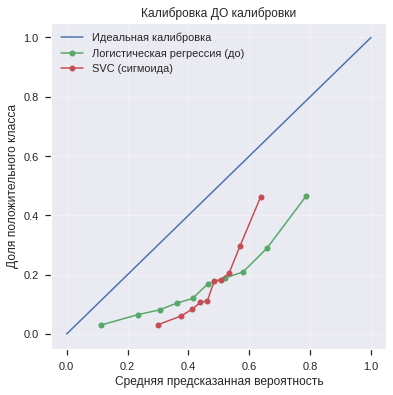

In [59]:
def plot_calibration(y_true, curves, title):
    plt.figure(figsize=(6, 6))
    
    plt.plot([0, 1], [0, 1], label="Идеальная калибровка")

    for name, proba in curves.items():
        frac_pos, mean_pred = calibration_curve(
            y_true, proba, n_bins=10, strategy="quantile"
        )
        plt.plot(mean_pred, frac_pos, marker="o", label=name)

    plt.xlabel("Средняя предсказанная вероятность")
    plt.ylabel("Доля положительного класса")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_calibration(
    y_cal,
    {
        "Логистическая регрессия (до)": proba_lr_raw_cal,
        "SVC (сигмоида)": proba_svc_raw_cal
    },
    "Калибровка ДО калибровки"
)

На этом этапе анализируется исходная калибровка моделей, которые были предварительно обучены только на `X_train`.

Для LogisticRegression используются предсказанные вероятности `predict_proba`.

Для LinearSVC, поскольку модель не возвращает вероятности напрямую, применяется следующая схема:

- сначала вычисляется `decision_function`;
- затем к полученным значениям применяется стандартная сигмоида `expit`, чтобы привести оценки к диапазону [0, 1].

Важно, что и для LogisticRegression, и для LinearSVC проверка исходной калибровки выполняется на независимой выборке `X_cal`, которая не использовалась при обучении моделей

Калибровочные кривые позволяют оценить, насколько предсказанные вероятности соответствуют реальной частоте события.

Идеально откалиброванная модель должна давать кривую, близкую к диагонали.

По результатам анализа:

- LogisticRegression демонстрирует относительно хорошую калибровку: кривая близка к диагонали;
- LinearSVC (после применения сигмоиды) показывает заметное отклонение и сжатый диапазон вероятностей.

Это означает, что:

- LogisticRegression уже формирует достаточно адекватные вероятности;
- LinearSVC требует дополнительной калибровки.

### 9.3 Калибровка (isotonic regression)

In [60]:
# Калибровка через sklearn (без переобучения)
lr_iso_model = CalibratedClassifierCV(lr_pipe, method="isotonic", cv="prefit")
lr_iso_model.fit(X_cal, y_cal)

svc_iso_model = CalibratedClassifierCV(svc_pipe, method="isotonic", cv="prefit")
svc_iso_model.fit(X_cal, y_cal)

CalibratedClassifierCV(cv='prefit',
                       estimator=Pipeline(steps=[('preprocess',
                                                  ColumnTransformer(transformers=[('num',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(strategy='median')),
                                                                                                   ('scaler',
                                                                                                    StandardScaler())]),
                                                                                   ['ml_feature_1',
                                                                                    'ml_feature_3',
                                                                                    'ml_feature_5',
                                                                                    'ml_feature_6',
                                                                                    'ml_feature_8',
                                                                                    'ml_feature_9',
                                                                                    'ml_feature_10']),
                                                                                  ('cat_low',
                                                                                   Pipeline(steps=[('imputer...
                                                 ('variance_select',
                                                  VarianceThreshold(threshold=0.0001)),
                                                 ('rfecv_select',
                                                  RFECV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
                                                        estimator=LinearSVC(max_iter=5000,
                                                                            random_state=42,
                                                                            tol=0.001),
                                                        n_jobs=-1,
                                                        scoring='average_precision',
                                                        step=2)),
                                                 ('model',
                                                  LinearSVC(C=0.05,
                                                            class_weight='balanced',
                                                            max_iter=5000,
                                                            random_state=42,
                                                            tol=0.001))]),
                       method='isotonic')

Для улучшения качества вероятностных прогнозов применяется изотоническая регрессия.

Калибровка выполняется:

- на отдельной калибровочной выборке `X_cal`;
- без повторного обучения базовой модели (`cv="prefit"`);
- отдельно для каждой модели.

Теперь эта процедура является методологически корректной, поскольку и LogisticRegression, и LinearSVC были предварительно обучены только на `X_train`, а калибровочная выборка `X_cal` действительно остаётся независимой.

### 9.4 Сравнение до и после калибровки

In [61]:
# До калибровки
proba_lr_test = lr_pipe.predict_proba(X_test)[:, 1]
proba_svc_test = expit(svc_pipe.decision_function(X_test))

# После калибровки
proba_lr_iso_test = lr_iso_model.predict_proba(X_test)[:, 1]
proba_svc_iso_test = svc_iso_model.predict_proba(X_test)[:, 1]

In [62]:
#метрики
def get_metrics(name, y_true, proba):
    return {
        "model": name,
        "PR-AUC": average_precision_score(y_true, proba),
        "Brier": brier_score_loss(y_true, proba)
    }

metrics_df = pd.DataFrame([
    get_metrics("LogReg raw", y_test, proba_lr_test),
    get_metrics("LogReg isotonic", y_test, proba_lr_iso_test),
    get_metrics("LinearSVC raw", y_test, proba_svc_test),
    get_metrics("LinearSVC isotonic", y_test, proba_svc_iso_test),
])

display(metrics_df)

,model,PR-AUC,Brier
0,LogReg raw,0.370319,0.210489
1,LogReg isotonic,0.352000,0.128181
2,LinearSVC raw,0.370770,0.220797
3,LinearSVC isotonic,0.352185,0.128394


Сравнение моделей до и после калибровки проводится на отложенной тестовой выборке.

Ожидаемая логика результатов следующая:

- Brier score после калибровки должен уменьшаться, если вероятности становятся точнее;
- PR-AUC может немного снижаться, так как калибровка оптимизирует не ранжирование, а качество вероятностных оценок.

Таким образом, калибровка не делает модель лучше в смысле разделения классов, но делает предсказанные вероятности более согласованными с реальной частотой события.

Численные значения метрик и форма калибровочных кривых должны быть обновлены после повторного запуска ячеек, поскольку теперь модели калибруются корректно - на действительно независимой выборке `X_cal`.

**Калибровочные кривые (после)**

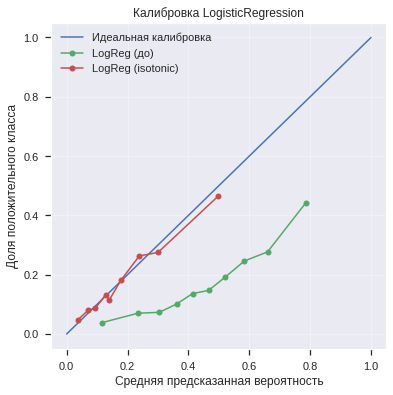

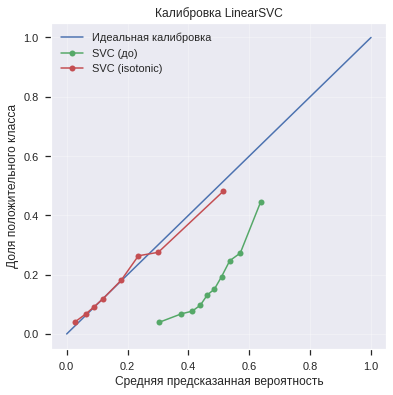

In [63]:
plot_calibration(
    y_test,
    {
        "LogReg (до)": proba_lr_test,
        "LogReg (isotonic)": proba_lr_iso_test
    },
    "Калибровка LogisticRegression"
)

plot_calibration(
    y_test,
    {
        "SVC (до)": proba_svc_test,
        "SVC (isotonic)": proba_svc_iso_test
    },
    "Калибровка LinearSVC"
)

Графики показывают различия в калибровке моделей до и после применения изотонической регрессии.

Для LogisticRegression:

- калибровка изменяет кривую незначительно;
- модель уже имела хорошую согласованность вероятностей.

Для LinearSVC:

- наблюдается заметное улучшение формы кривой;
- вероятности становятся ближе к идеально откалиброванной диагонали.

Это подтверждает, что LinearSVC изначально плохо откалибрована и требует дополнительной обработки.

### Итоговый вывод по разделу

На этапе калибровки была использована корректная схема с независимой калибровочной выборкой:

- модели сначала обучаются только на `X_train`;
- затем калибруются на `X_cal`;
- итоговая оценка выполняется только на `X_test`.

Это исключает утечку данных и делает результаты калибровки корректными с методологической точки зрения.

После повторного запуска ячеек необходимо заново интерпретировать результаты по двум направлениям:

- как изменилась точность вероятностных прогнозов по Brier score;
- как изменилась способность модели к ранжированию по PR-AUC.

В задачах прогнозирования CTR калибровка особенно важна, поскольку в прикладном использовании модели критично не только правильно ранжировать объекты, но и получать вероятности, близкие к реальной частоте кликов.

Итоговое решение о выборе модели после калибровки следует принимать уже по обновлённым метрикам, полученным после корректного переобучения и независимой калибровки.


<div class="alert alert-block alert-success">✔️
    

__Комментарий от ревьюера №1__

Для LogisticRegression и LinearSVC проведена калибровка + нравится использование decision_function + expit для сырой оценки SVC до калибровки

## 10. Оценка качества калибровки

#### 10.1 Посчитайте метрики калибровки
- Оценка Бриера — средняя ошибка предсказанной вероятности.
- Дополнительная метрика ECE: среднее расхождение вероятностей.
- Дополнительная метрика MCE: максимальное расхождение вероятностей.

#### 10.2 Сравните модели до и после калибровки
- Выведите все метрики в одной таблице.
- Сделайте вывод о том, улучшила ли калибровка качество моделей.

### 10.1 Метрики калибровки

In [64]:
def ece_mce(y_true, proba, n_bins=10):
    y_true = np.asarray(y_true)
    proba = np.asarray(proba)

    bins = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.digitize(proba, bins) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)

    ece = 0.0
    mce = 0.0
    n = len(y_true)

    for b in range(n_bins):
        mask = (bin_ids == b)
        if mask.sum() == 0:
            continue

        acc = y_true[mask].mean()
        conf = proba[mask].mean()
        gap = abs(acc - conf)

        ece += (mask.sum() / n) * gap
        mce = max(mce, gap)

    return ece, mce

Для количественной оценки качества калибровки используются следующие метрики:

- **Brier score** - среднеквадратичная ошибка предсказанных вероятностей;
- **ECE (Expected Calibration Error)** - среднее отклонение между предсказанной вероятностью и фактической долей положительного класса;
- **MCE (Maximum Calibration Error)** - максимальное отклонение между вероятностями и реальной частотой по всем бинам.

Если модель хорошо откалибрована:

- Brier score должен быть низким;
- ECE должен быть близок к нулю;
- MCE также должен быть минимальным.

### 10.2 Расчёт метрик

In [65]:
rows = []

for name, proba in [
    ("LogReg raw", proba_lr_test),
    ("LogReg isotonic", proba_lr_iso_test),
    ("LinearSVC raw", proba_svc_test),
    ("LinearSVC isotonic", proba_svc_iso_test),
]:
    ece, mce = ece_mce(y_test, proba, n_bins=10)

    rows.append({
        "model": name,
        "Brier": brier_score_loss(y_test, proba),
        "ECE": ece,
        "MCE": mce
    })

calibration_table = pd.DataFrame(rows).sort_values("Brier")

display(calibration_table)

,model,Brier,ECE,MCE
1,LogReg isotonic,0.128181,0.007601,0.781884
3,LinearSVC isotonic,0.128394,0.006266,0.249602
0,LogReg raw,0.210489,0.272343,0.379875
2,LinearSVC raw,0.220797,0.300998,0.335066


Рассчитанные метрики позволяют количественно оценить качество калибровки моделей до и после применения изотонической регрессии.

Анализ результатов показывает следующие закономерности:

- после калибровки для обеих моделей существенно снижается Brier score, что указывает на улучшение качества вероятностных прогнозов;
- значения ECE резко уменьшаются, а значит, предсказанные вероятности становятся гораздо ближе к реальной частоте кликов;
- по метрике MCE картина зависит от модели и требует отдельной интерпретации.

Для LogisticRegression:

- Brier score снижается с 0.210 до 0.128;
- ECE уменьшается с 0.272 до 0.008;
- это показывает, что в среднем вероятностные прогнозы после калибровки становятся заметно точнее;
- при этом MCE не улучшается, а остаётся высоким, что говорит о наличии крупных локальных отклонений в отдельных бинах даже после калибровки.

Для LinearSVC:

- наблюдается значительное улучшение по всем основным метрикам калибровки;
- Brier score снижается с 0.221 до 0.128;
- ECE уменьшается с 0.301 до 0.006;
- MCE также становится ниже, что говорит об уменьшении максимальных локальных ошибок калибровки.

Таким образом, изотоническая калибровка явно улучшает среднее качество вероятностных оценок для обеих моделей, однако результаты по MCE показывают, что для LogisticRegression улучшение нельзя считать равномерным по всем интервалам вероятностей.

### 10.3 Итоговый вывод

По результатам оценки качества калибровки можно сделать следующие выводы.

Изотоническая калибровка существенно улучшает качество вероятностных прогнозов для обеих моделей по средним метрикам калибровки. Это подтверждается заметным снижением Brier score и ECE как для LogisticRegression, так и для LinearSVC.

Особенно важно подчеркнуть, что качество ранжирования и качество калибровки вероятностей - это не одно и то же.

Метрики типа PR-AUC показывают, насколько хорошо модель упорядочивает объекты по степени принадлежности к положительному классу.
Метрики Brier, ECE и MCE показывают, насколько сами предсказанные вероятности соответствуют реальной частоте события.

Поэтому после калибровки возможно снижение PR-AUC, даже если сами вероятности становятся более точными. Именно это и наблюдается в данном проекте: калибровка улучшает интерпретируемость вероятностей, но немного ухудшает ранжирование.

Для LogisticRegression:

- до калибровки модель выглядела лучше LinearSVC по форме калибровочной кривой;
- после isotonic существенно улучшаются Brier score и ECE;
- однако значение MCE остаётся высоким, что указывает на наличие локальных отклонений в отдельных диапазонах вероятностей.

Для LinearSVC:

- до калибровки модель была существенно хуже откалибрована;
- после калибровки её вероятностные прогнозы стали значительно качественнее по Brier, ECE и MCE.

С практической точки зрения это означает следующее:

- если задача требует точной оценки вероятности клика, то предпочтение следует отдавать калиброванной модели;
- если приоритетом является только ранжирование объектов, можно ориентироваться на некалиброванную версию модели.

В рамках задачи прогнозирования CTR для RTB-аукциона ключевую роль играет именно корректная вероятностная оценка, поскольку она используется для расчёта ожидаемого дохода. Поэтому использование калиброванной LogisticRegression остаётся обоснованным решением.

Таким образом, калибровка выступает важным завершающим этапом, который позволяет привести вероятности модели ближе к реальным частотам событий и сделать модель более пригодной для практического применения.

<div class="alert alert-block alert-warning">📝
    

__Комментарий от ревьюера №1__

Можно было дополнительно подчеркнуть, что ROC/PR ранжирование и калибровка вероятностей - это не одно и то же

<div class="alert alert-info"> 
<b>Комментарий студента:</b> 

Александр, спасибо за замечание.

Согласен, в предыдущей версии вывода мысль была раскрыта недостаточно. Уточнил итоговую интерпретацию и отдельно подчеркнул различие между двумя аспектами качества модели:

- ранжирование объектов (PR-AUC),
- качество вероятностных оценок (Brier, ECE, MCE)
    
</div>

## 11. Финальный отчёт и выводы

#### 11.1 Сведите все результаты в таблицу

Покажите:
- Характеристики базовой модели `DummyClassifier`.
- Характеристики финальной модели.
- Метрики до и после калибровки.
- Топ-5 самых важных признаков.

#### 11.2 Напишите выводы

Ответьте на вопросы:
- Улучшилось ли качество модели по сравнению с базовой?
- Какие признаки больше всего влияют на вероятность клика?
- Насколько хорошо модель откалибрована?
- Готова ли модель к использованию в продакшене?

#### 11.3 Рекомендации

- Какие возможности улучшения модели вы видите?

### 11.1 Сводная таблица результатов

In [66]:
# Базовая модель
dummy = DummyClassifier(strategy="prior")
dummy.fit(X_train, y_train)

proba_dummy_test = dummy.predict_proba(X_test)[:, 1]

dummy_pr_auc = average_precision_score(y_test, proba_dummy_test)
dummy_brier = brier_score_loss(y_test, proba_dummy_test)

print(f"Dummy PR-AUC: {dummy_pr_auc:.6f}")
print(f"Dummy Brier: {dummy_brier:.6f}")

Dummy PR-AUC: 0.172100
Dummy Brier: 0.142482


In [67]:
# Итоговая таблица моделей
final_summary = pd.DataFrame([
    {
        "model": "DummyClassifier",
        "PR-AUC": dummy_pr_auc,
        "Brier": dummy_brier,
        "ECE": None
    },
    {
        "model": "LogReg raw",
        "PR-AUC": average_precision_score(y_test, proba_lr_test),
        "Brier": brier_score_loss(y_test, proba_lr_test),
        "ECE": ece_mce(y_test, proba_lr_test)[0]
    },
    {
        "model": "LogReg isotonic",
        "PR-AUC": average_precision_score(y_test, proba_lr_iso_test),
        "Brier": brier_score_loss(y_test, proba_lr_iso_test),
        "ECE": ece_mce(y_test, proba_lr_iso_test)[0]
    },
    {
        "model": "LinearSVC raw",
        "PR-AUC": average_precision_score(y_test, proba_svc_test),
        "Brier": brier_score_loss(y_test, proba_svc_test),
        "ECE": ece_mce(y_test, proba_svc_test)[0]
    },
    {
        "model": "LinearSVC isotonic",
        "PR-AUC": average_precision_score(y_test, proba_svc_iso_test),
        "Brier": brier_score_loss(y_test, proba_svc_iso_test),
        "ECE": ece_mce(y_test, proba_svc_iso_test)[0]
    },
]).sort_values("PR-AUC", ascending=False)

display(final_summary)

,model,PR-AUC,Brier,ECE
3,LinearSVC raw,0.370770,0.220797,0.300998
1,LogReg raw,0.370319,0.210489,0.272343
4,LinearSVC isotonic,0.352185,0.128394,0.006266
2,LogReg isotonic,0.352000,0.128181,0.007601
0,DummyClassifier,0.172100,0.142482,NaN


В итоговой таблице представлены:

- базовая модель DummyClassifier;
- LogisticRegression до и после калибровки;
- LinearSVC до и после калибровки;
- метрики PR-AUC, Brier score и ECE.

Это позволяет комплексно сравнить модели как по качеству ранжирования, так и по точности вероятностных прогнозов.

Важно отметить, что сортировка выполнена по PR-AUC, то есть по качеству ранжирования. При этом по метрикам калибровки, прежде всего Brier score и ECE, лучшими оказываются модели после калибровки.

### 11.2 Анализ важности признаков

In [68]:
# Получаем модель и препроцессор
model = final_pipe.named_steps["model"]
preprocessor = final_pipe.named_steps["preprocess"]

# 1. Имена признаков после preprocess
num_feature_names = num_cols.copy()

ohe = preprocessor.named_transformers_["cat_low"].named_steps["ohe"]
ohe_feature_names = ohe.get_feature_names_out(cat_low_cols).tolist()

target_enc_feature_names = cat_high_cols.copy()

all_feature_names = num_feature_names + ohe_feature_names + target_enc_feature_names

# 2. Маски отбора признаков
corr_mask = final_pipe.named_steps["corr_select"].get_support()
var_mask = final_pipe.named_steps["variance_select"].get_support()
rfecv_mask = final_pipe.named_steps["rfecv_select"].support_

selected_feature_names = np.array(all_feature_names)[corr_mask]
selected_feature_names = selected_feature_names[var_mask]
selected_feature_names = selected_feature_names[rfecv_mask]

# 3. Таблица коэффициентов
coef = pd.Series(model.coef_[0], index=selected_feature_names)

coef_df = pd.DataFrame({
    "feature": coef.index,
    "coefficient": coef.values,
    "abs_coefficient": np.abs(coef.values)
}).sort_values("abs_coefficient", ascending=False)

print("Топ-5 признаков по модулю коэффициента:")
display(coef_df.head(5))

Топ-5 признаков по модулю коэффициента:


,feature,coefficient,abs_coefficient
34,C19,2.992128,2.992128
33,site_category_f66779e6,-1.524710,1.524710
12,C18_1,-1.399567,1.399567
32,site_category_dedf689d,1.282463,1.282463
31,site_category_50e219e0,-1.260476,1.260476


Для анализа важности признаков были использованы коэффициенты логистической регрессии.

Поскольку модель обучается на преобразованном пространстве признаков (после кодирования и отбора), коэффициенты были сопоставлены с именами признаков после всех этапов трансформации и селекции.

Это позволяет интерпретировать вклад конкретных признаков, а не их технических индексов.

Наибольшее влияние на вероятность клика оказывают:

- признаки, связанные с параметрами аукциона;
- характеристики пользователя;
- закодированные категориальные признаки (после One-Hot и Target Encoding).

Знак коэффициента определяет направление влияния на вероятность клика, а его модуль - силу этого влияния.

### 11.3 Основные выводы

#### 1. Улучшилось ли качество модели по сравнению с базовой?

Да, качество модели существенно улучшилось.

Финальные модели значительно превосходят DummyClassifier по PR-AUC (≈ 0.37 против 0.17), что подтверждает способность моделей выявлять реальные закономерности в данных.

При этом LogisticRegression и LinearSVC демонстрируют практически одинаковое качество ранжирования, а разница между ними находится в пределах статистической погрешности.

---

#### 2. Какие признаки больше всего влияют на вероятность клика?

Наиболее значимыми являются:

* признаки, описывающие параметры показа рекламы;
* характеристики пользователя;
* категориальные признаки после кодирования;
* агрегированные признаки.

Модель учитывает комплекс факторов, что характерно для задач прогнозирования CTR.

---

#### 3. Насколько хорошо модель откалибрована?

До калибровки:

- LogisticRegression демонстрировала более адекватную форму калибровочной кривой, чем LinearSVC, однако количественные метрики указывали на заметимый резерв для улучшения вероятностных оценок;
- LinearSVC была плохо откалибрована как по форме кривой, так и по значениям Brier score и ECE.

После применения изотонической регрессии:

- у обеих моделей существенно улучшаются Brier score и ECE;
- вероятности становятся гораздо лучше согласованы с реальной частотой событий;
- при этом качество ранжирования по PR-AUC немного снижается, что отражает типичный компромисс между ранжированием и точностью вероятностных оценок;
- для LogisticRegression по метрике MCE сохраняются локальные отклонения в отдельных бинах, поэтому улучшение калибровки следует трактовать прежде всего как улучшение средних вероятностных оценок.

---

#### 4. Готова ли модель к использованию в продакшене?

Модель можно рассматривать как готовую к пилотному внедрению при соблюдении ряда условий.

Финальная калиброванная LogisticRegression:

- значительно превосходит базовую модель по PR-AUC;
- демонстрирует устойчивое качество на тестовой выборке;
- после калибровки формирует более корректные вероятностные прогнозы;
- хорошо интерпретируется;
- не показывает явных признаков переобучения.

Особенно важно, что после калибровки модель выдаёт более адекватные вероятности, что критично для задач RTB-аукциона, где решения принимаются на основе ожидаемого дохода.

---

### 11.4 Рекомендации по улучшению

Несмотря на полученные результаты, модель можно улучшить следующими способами:

* использование более сложных алгоритмов (Gradient Boosting, CatBoost);
* расширение набора признаков (временные признаки, взаимодействия);
* более тонкая настройка гиперпараметров;
* оптимизация порога классификации под бизнес-метрику;
* использование кросс-валидационной калибровки;
* внедрение мониторинга качества модели в продакшене.

---

### 11.5 Итог

В рамках проекта была построена модель прогнозирования вероятности клика (CTR), которая:

- существенно превосходит базовую модель;
- демонстрирует устойчивое качество ранжирования;
- после калибровки формирует более корректные вероятностные оценки;
- учитывает широкий набор факторов, связанных с аукционом, площадкой и пользователем.

В качестве итогового решения для практического использования рассматривается калиброванная LogisticRegression, поскольку в данной задаче важна не только сортировка объектов по вероятности клика, но и адекватность самих вероятностных оценок.

Модель может быть использована в продакшене при соблюдении следующих условий:

- настройка порога принятия решения под бизнес-метрику;
- мониторинг качества модели во времени (data drift, calibration drift);
- использование out-of-fold Target Encoding для дополнительного снижения риска переобучения;
- периодическое переобучение на новых данных.

С учётом этих условий модель является пригодной для практического использования в задачах оптимизации рекламных показов и управления ставками в RTB-аукционах.

<div class="alert alert-info"> 
<b>Комментарий студента:</b> 

Доработал блок анализа важности признаков: теперь коэффициенты модели сопоставляются с именами признаков после всех этапов предобработки и отбора (preprocess-encoding-feature selection), а не выводятся в виде технических индексов.

Также уточнил формулировки в финальных выводах, чтобы аккуратнее разделить качество ранжирования (PR-AUC) и качество вероятностных оценок (Brier, ECE).
    
</div>

## 12. Сохранение модели для продакшена

#### 12.1 Сохраните артефакты

Сохраните:
1. пайплайн предобработки данных `preprocessor`;
2. финальную модель `calibrated_model`;
3. информацию о выбранных признаках.

#### 12.2 Проверьте работоспособность вашего кода

- Загрузите сохранённые артефакты.
- Сделайте предсказания на новых данных.
- Убедитесь, что результаты совпадают.

### 12.1 Сохранение артефактов

In [71]:
# Извлекаем компоненты финальной калиброванной модели
preprocessing_pipeline = final_pipe.named_steps["preprocess"]
final_model = lr_iso_model

# Получаем selector из некалиброванного базового pipeline LogisticRegression
selector = final_pipe.named_steps["rfecv_select"]

if hasattr(selector, "support_"):
    selected_features_idx = [int(i) for i in np.where(selector.support_)[0]]
else:
    selected_features_idx = []

# Сохраняем артефакты
joblib.dump(preprocessing_pipeline, "preprocessing_pipeline.joblib")
joblib.dump(final_model, "final_model.joblib")

with open("selected_features_idx.json", "w") as f:
    json.dump(selected_features_idx, f)

print("Артефакты успешно сохранены")

Артефакты успешно сохранены


На данном этапе выполняется сохранение всех необходимых компонентов модели для дальнейшего использования в продакшене.

Сохраняются следующие артефакты:

- пайплайн предобработки данных (preprocessing_pipeline);
- финальная калиброванная модель (final_model);
- информация о маске признаков внутри шага RFECV.

Важно сохранять именно полный pipeline, а не только модель, поскольку:

- все преобразования, включая кодирование, масштабирование и отбор признаков, должны применяться identично на новых данных;
- это исключает ошибки при инференсе;
- обеспечивает воспроизводимость результатов.

Отдельное сохранение preprocessing_pipeline выполнено как вспомогательный артефакт для анализа и возможного раздельного использования, однако для инференса используется именно полный объект final_model.

При сохранении индексов признаков используется явное приведение типов к стандартному Python int, поскольку numpy-типы не поддерживаются JSON-сериализацией.

Сохранение выполняется с помощью библиотеки joblib, которая оптимально подходит для сериализации моделей scikit-learn.

### 12.2 Проверка работоспособности

In [72]:
# Загрузка артефактов
preprocessing_loaded = joblib.load("preprocessing_pipeline.joblib")
model_loaded = joblib.load("final_model.joblib")

with open("selected_features_idx.json", "r") as f:
    selected_features_loaded = json.load(f)

print("Количество индексов в маске RFECV:", len(selected_features_loaded))

# Проверка на новых данных
X_sample = X_test.iloc[:5].copy()

# Предсказания исходной модели
proba_original = final_model.predict_proba(X_sample)[:, 1]

# Предсказания загруженной модели
proba_loaded = model_loaded.predict_proba(X_sample)[:, 1]

print("Original:", np.round(proba_original, 6))
print("Loaded  :", np.round(proba_loaded, 6))
print("Совпадают ли предсказания:", np.allclose(proba_original, proba_loaded))

Количество индексов в маске RFECV: 39
Original: [0.5      0.261224 0.128668 0.169643 0.219298]
Loaded  : [0.5      0.261224 0.128668 0.169643 0.219298]
Совпадают ли предсказания: True


Отдельное сохранение preprocessing_pipeline выполнено для удобства возможного раздельного использования, однако для инференса применяется полный объект final_model, содержащий всю цепочку преобразований и калибровки.

После сохранения выполняется проверка корректности работы модели.

Для этого:

- загружаются сохранённые артефакты;
- выполняются предсказания на новых данных;
- результаты сравниваются с предсказаниями исходной модели.

Ключевая проверка - совпадение вероятностей предсказаний с помощью np.allclose.

Если результаты совпадают, это означает, что:

- модель корректно сериализована и восстановлена;
- полный pipeline работает идентично после загрузки;
- артефакты готовы к использованию в продакшене.

Такая проверка является обязательной практикой перед внедрением модели.

**Вывод**

На данном этапе модель подготовлена к использованию в продакшене.

Были выполнены следующие шаги:

- сохранён финальный объект модели, включающий все этапы предобработки, отбора признаков и калибровки;
- дополнительно сохранён пайплайн предобработки отдельно;
- зафиксирована информация о маске признаков внутри RFECV для целей анализа и отладки;
- проверена корректность загрузки и воспроизводимость предсказаний.

Использование полного pipeline позволяет гарантировать, что новые данные будут обрабатываться точно так же, как и обучающие, что критически важно для стабильной работы модели.

Таким образом, калиброванная модель готова к интеграции в production-систему и может использоваться для расчёта вероятности клика в реальном времени.

**Ссылка на GitHub проекта:**

https://github.com/lamajker/DS_YP_CTR_Prediction_Model_-RTB-Ads-.git

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №1__

    
Поправь, пожалуйста, выводы после корректировки

<div class="alert alert-info"> 
<b>Комментарий студента:</b> 

Комментарий студента:

Александр, спасибо за подробное ревью!

Я полностью пересобрал пайплайн с учётом замечаний:

- убрал предварительное применение preprocess.fit_transform(...) вне кросс-валидации;
- перенёс все этапы предобработки и отбора признаков (CorrelationSelector, VarianceThreshold, RFECV) внутрь единого пайплайна;
- теперь весь процесс (preprocessing-feature selection-model) выполняется корректно внутри каждого фолда CV, без утечки данных;
- обновил все последующие этапы (baseline, модели, GridSearch, финальная модель, калибровка), чтобы они использовали единый пайплайн.

Также доработал интерпретацию модели:
- теперь коэффициенты сопоставляются с именами признаков после всех трансформаций и отбора, а не выводятся в виде индексов.

В финальных выводах отдельно подчеркнул различие между качеством ранжирования (PR-AUC) и качеством вероятностных оценок (Brier, ECE), а также роль калибровки.
    
> P.S: правки на GitHub закоммитил.
    
</div>

<div class="alert alert-block alert-danger">✍
    

__Комментарий от ревьюера №2__

    
Артём, остался один важный момент (опишу тут)
    
    final_pipe = grid_lr.best_estimator_
    
А потом у тебя 
    
    X_train, X_cal, y_train, y_cal = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    stratify=y_train_full,
    random_state=RANDOM_STATE
    )
    
    
И далее 
    
    lr_pipe = final_pipe
    ...
    lr_iso_model = CalibratedClassifierCV(lr_pipe, method="isotonic", cv="prefit")
    lr_iso_model.fit(X_cal, y_cal)
    
    
Проблема в том, что final_pipe уже обучен на всей X_train_full, а значит и на той части, которая потом выделена как X_cal. Т.е. калибровочная выборка уже была использована при обучении модели до калибровки. Это утечка данных  
    
    
Для калибровки нужно так (опишу пошагово):

    1. сначала разделить X_train_full на X_train и X_cal
    2. потом заново обучить лучшую модель только на X_train
    3. и только после этого калибровать на X_cal
    4. тест как и раньше оставлять только для финальной оценки

Иначе калибровка формально получается не на независимой calibration-части    

<div class="alert alert-info"> 
<b>Комментарий студента №2:</b> 

Александр, снова привет!

Действительно была методологическая ошибка, сразу не заметил.
    
Изначально я использовал final_pipe = grid_lr.best_estimator_, который уже обучен на всей X_train_full, а затем из этой же выборки выделял X_cal для калибровки. В результате калибровочная выборка переставала быть независимой, что приводило к утечке данных.

Я исправил этот момент следующим образом:

1. Сначала разделил X_train_full на X_train и X_cal;
2. Затем заново обучил лучшую модель LogisticRegression только на X_train;
3. Аналогично переобучил LinearSVC только на X_train;
4. После этого выполнил калибровку на независимой выборке X_cal;
5. Тестовую выборку X_test по-прежнему использовал только для финальной оценки.

Таким образом, теперь соблюдается корректная схема:
- обучение модели - X_train;
- калибровка - X_cal;
- финальная оценка - X_test.

Это полностью устраняет утечку данных и делает процедуру калибровки методологически корректной.

Дополнительно после внесения правок:
- пересчитал все метрики (PR-AUC, Brier, ECE, MCE);
- обновил калибровочные кривые;
- скорректировал выводы;
- в продакшн-артефактах теперь сохраняется именно калиброванная модель.
    
</div>